<a href="https://colab.research.google.com/github/HieuStudyingCS/Learning-AI-Journey/blob/main/Matrix_Calculus_Gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt
from IPython.display import Image, display, HTML

In [67]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Vector Calculus

Linear function

$$
\begin{aligned}f: \mathcal{R}^D &\to \mathcal{R} \\  \mathbf{x} &\mapsto f(\mathbf{x})\end{aligned}
$$

Ví dụ như dot product $f(\mathbf{x}) = \mathbf{x}^T\mathbf{x}$, được biểu diễn như sau

$$
\begin{aligned}f: \mathcal{R}^2 &\to \mathcal{R} \\ \mathbf{x} &\mapsto x_1^2 + x_2^2 \end{aligned}
$$

In this chapter, we will discuss how to compute gradients of functions

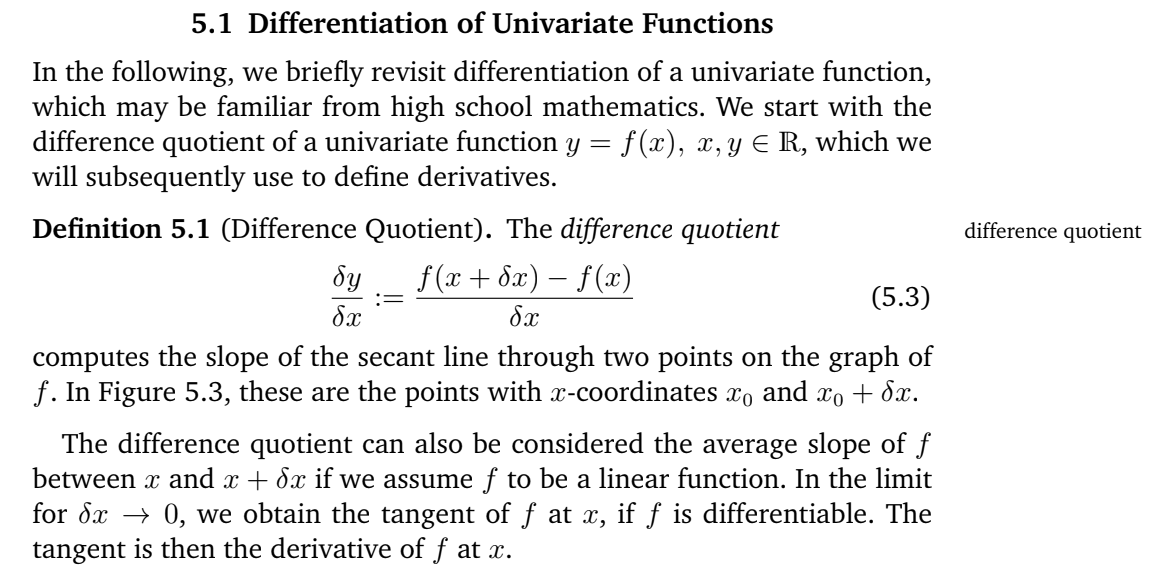

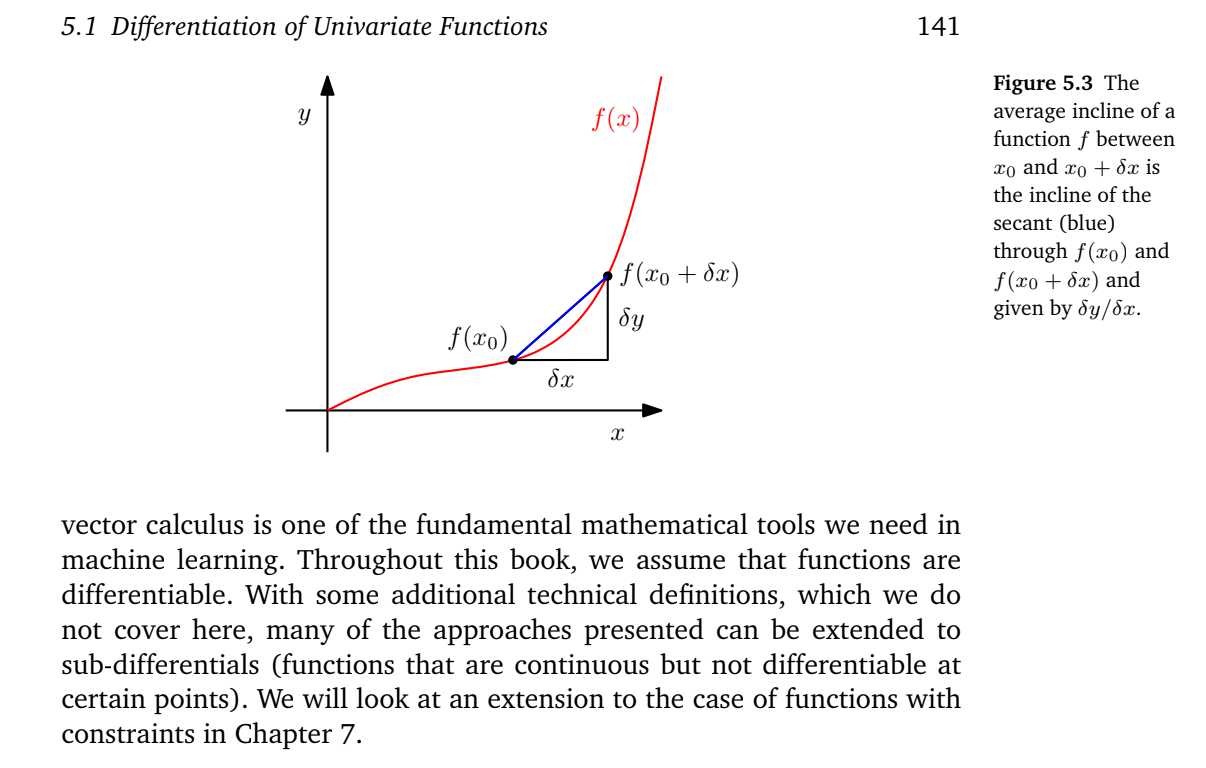

In [43]:
file_path_pic_1 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/1.png'
file_path_pic_2 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/2.png'
display(Image(filename=file_path_pic_2, width=600))
display(Image(filename=file_path_pic_1, width=600))

Trong bức ảnh trên thì tác giả thể hiện khái niệm của đạo hàm, tức là sự thay đổi của hàm số tại một thời điểm

Nhìn vào **figure 5.3** thì ta thấy được hệ số góc của đường thẳng màu xanh dương như sau:

$$
a = \tan(\alpha) = \frac{\delta y}{\delta x} = \frac{f(x_o + \delta x) - f(x_0)}{(x_0 + \delta x) - x_0} = \frac{f(x_o + \delta x) - f(x_0)}{\delta x}
$$

Khi $\delta x \to 0$, then $B(x_0 + \delta x, f(x_0 + \delta x)) \to A(x_0, f(x_0))$.

Nói cách khác thì lúc này đường thẳng màu xanh dương (là cát tuyến của $f(x)$) trở thành đường tiếp tuyến tại $A$ của $f(x)$. Và đường thẳng này mang theo thông tin của độ dốc của hàm số $f(x)$ tại $A$ → Khái niệm này người ta gọi là đạo hàm (derivative).

Công thức tổng quát như sau

$$
\frac{df}{dx} = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}
$$

Trong đó, $h = \delta x > 0$

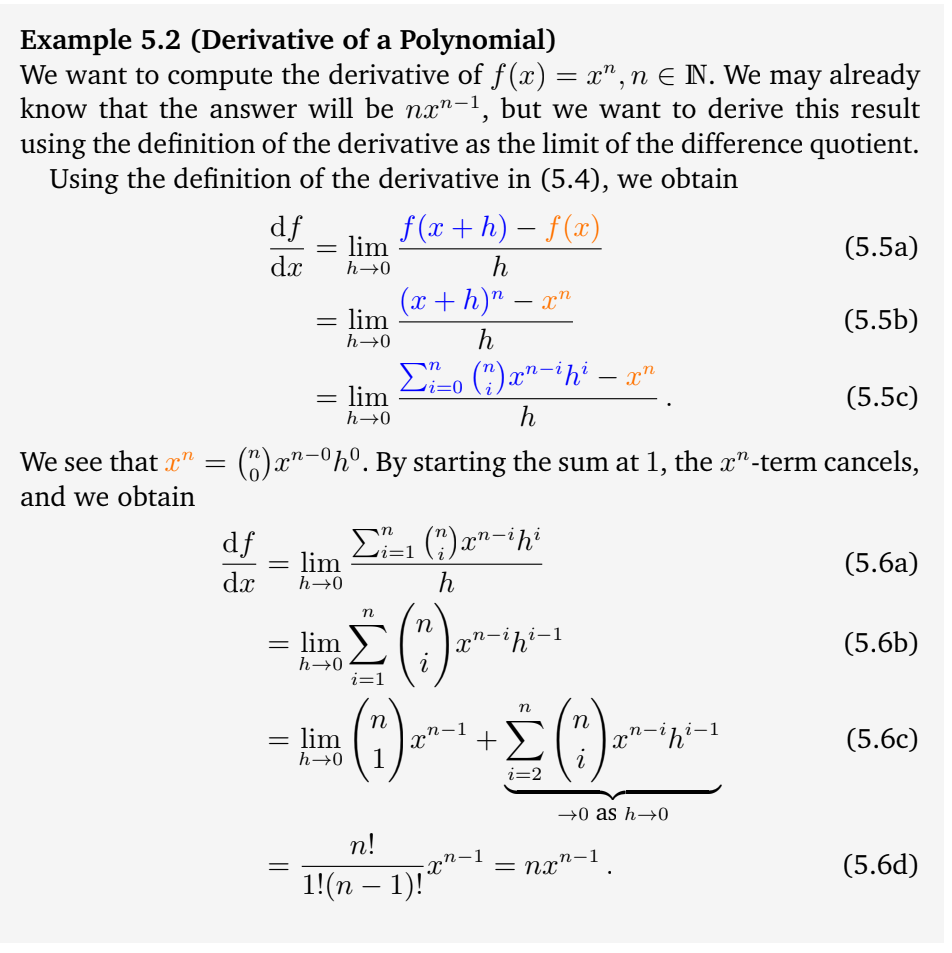

In [44]:
file_path_pic_3 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/3.png'
display(Image(filename=file_path_pic_3, width=600))

Đây là chứng minh lại công thức đạo hàm của hàm đa thức $f’(x) = (x^n)’ = nx^{n-1}$.

# Taylor Series

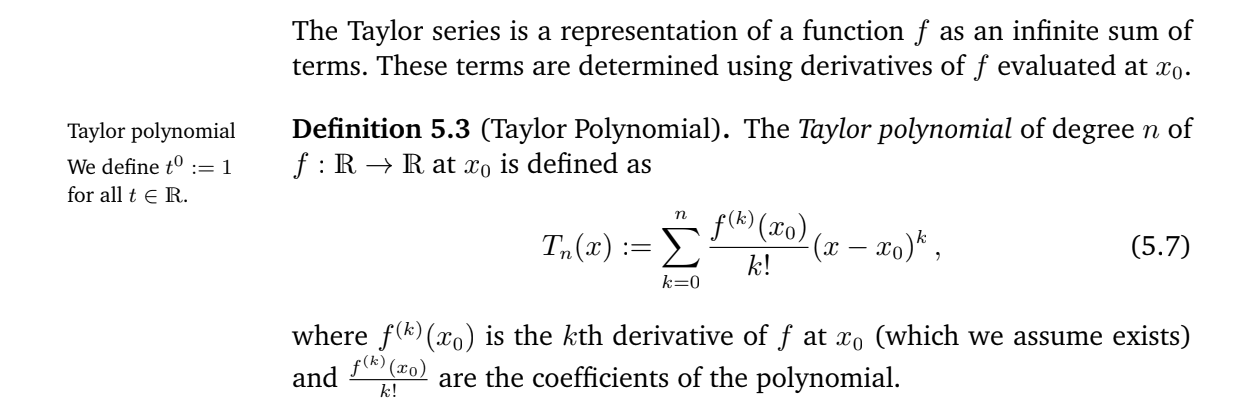

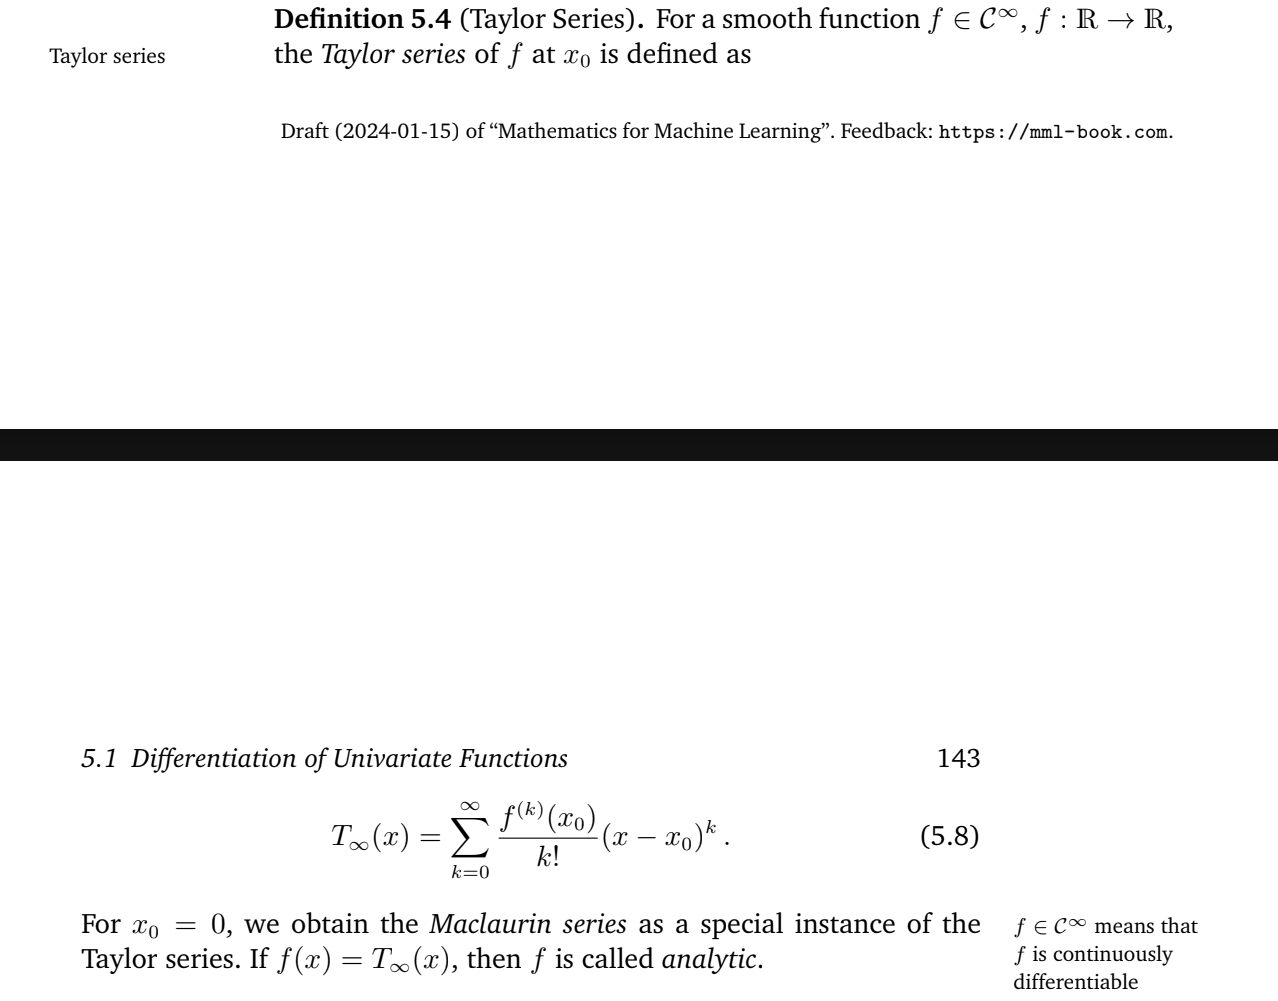

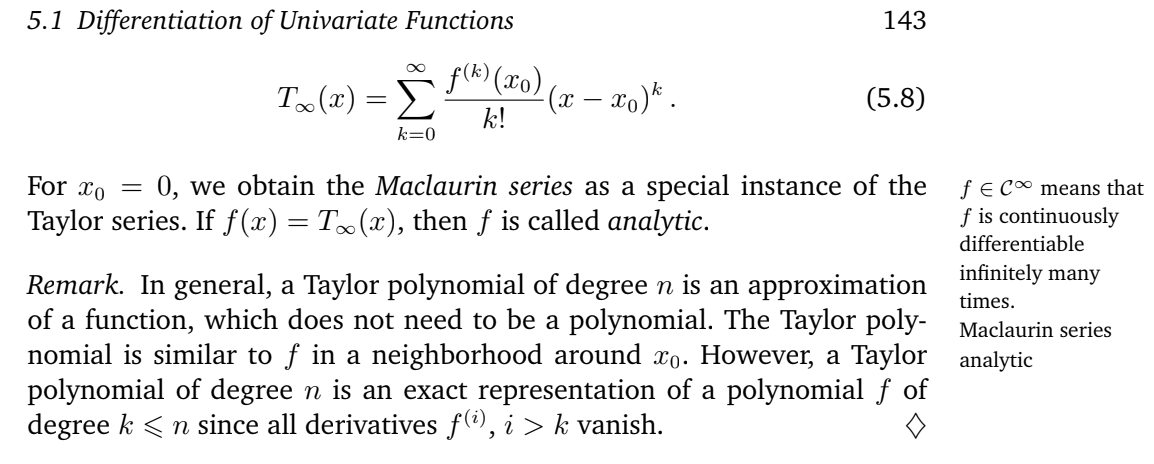

In [45]:
file_path_pic_4 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/4.png'
file_path_pic_5 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/5.png'
file_path_pic_6 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/6.png'
display(Image(filename=file_path_pic_4, width=600))
display(Image(filename=file_path_pic_5, width=600))
display(Image(filename=file_path_pic_6, width=600))

Đoạn cuối:

- Đa thức Taylor bậc $n$ được sử dụng để xấp xỉ một hàm số (không nhất thiết phải là đa thức) trong vùng lân cận của $x_0$.
- Nếu bản thân hàm $f$ đã là một đa thức có bậc $k \leqslant n$, thì đa thức Taylor bậc $n$ sẽ biểu diễn chính xác hoàn toàn hàm $f$ đó. Lý do là vì tất cả các đạo hàm bậc cao hơn $k$ (ký hiệu là $f^{(i)}$ với $i > k$) đều sẽ bằng 0.

Ví dụ sau đây sẽ thể hiện nếu $f$ là một hàm đa thức bậc $k \leq n$ thì đa thức Taylor bậc $n$ sẽ biểu diễn chính xác hoàn toàn hàm $f$:

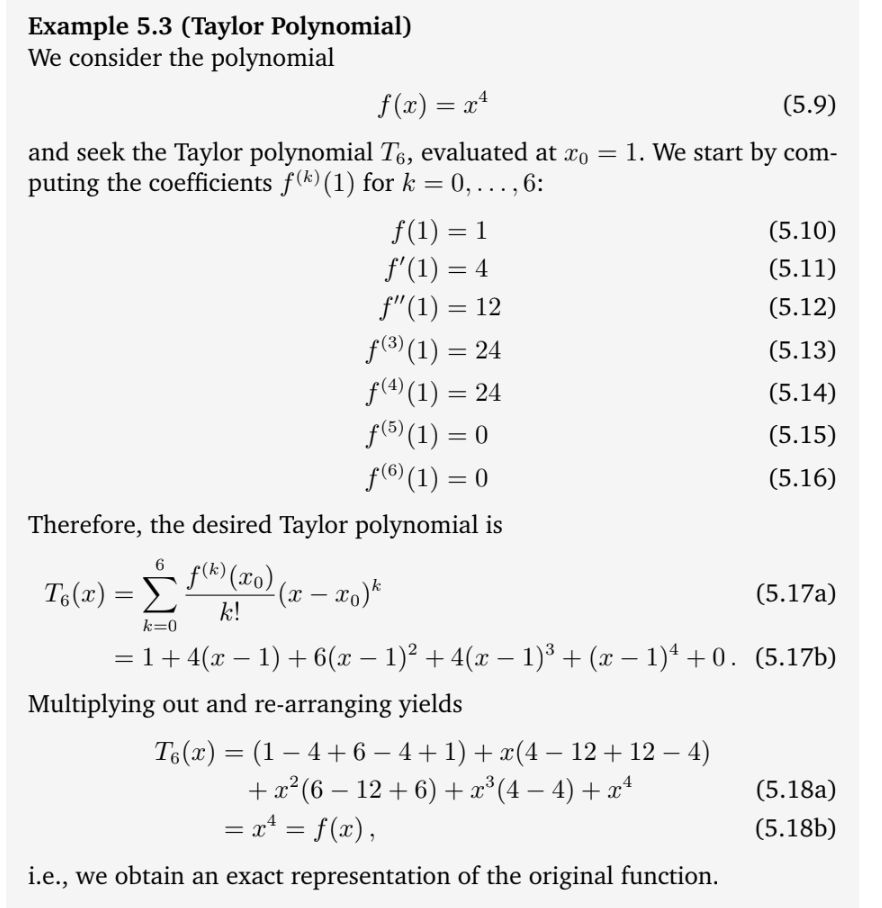

In [46]:
file_path_pic_7 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/7.png'
display(Image(filename=file_path_pic_7, width=600))

Chú ý kí hiệu: $f\in \mathcal{C}^\infty$ có nghĩa là hàm $f$ khả vi liên tục vô hạn lần (smooth)

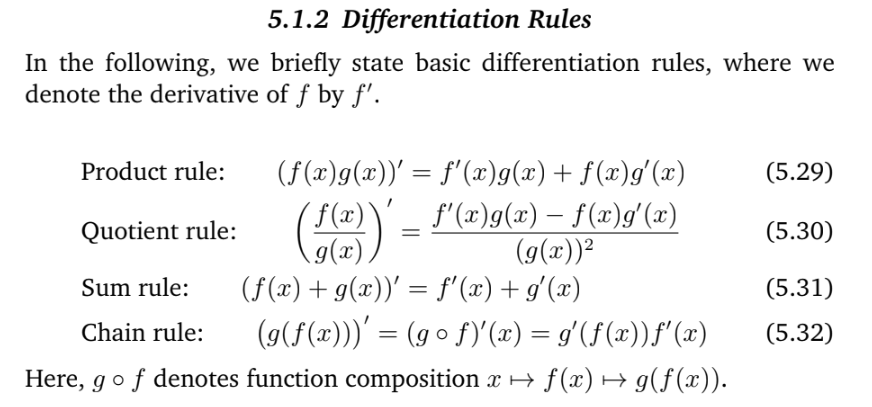

In [47]:
file_path_pic_8 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/8.png'
display(Image(filename=file_path_pic_8, width=600))

# Gradient

## Introduction

Trong phần trên thì mình đã tìm hiểu về Linear Functions, và đạo hàm cho hàm một biến. Nếu đạo hàm của hàm nhiều biến thì ta gọi phép đạo hàm này là Gradient.

- Được áp dụng cho hàm nhiều biến $f(x, y, z,\dots)$ hoặc $f(\mathbf{x})$ với $\mathbf{x}$ là một vector chứa nhiều biến.
- Gradient là tập hợp tất cả các đạo hàm riêng (partial derivatives) của hàm số đó theo từng biến. Và vector được tạo thành từ phép lấy Gradient sẽ chỉ theo hướng của hàm số tăng nhanh nhất từ một điểm cụ thể trong không gian đa chiều, và độ lớn của vector gradient này chính là tốc độ tăng đó.
- Như đã nói ở trên, kết quả của Gradient là một vector có cùng số chiều với không gian đầu vào.
- Ký hiệu: $\nabla f(\mathbf{x})$.
- **Ví dụ:** Nếu $f(x, y) = x^2 + y^3$, thì gradient là một véc-tơ chứa hai đạo hàm riêng:

$$
\nabla f(x, y) = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix} = \begin{bmatrix} 2x \\ 3y^2 \end{bmatrix}
$$

## Gradient của hàm trả về một số vô hướng (hàm vô hướng)

Hàm vô hướng được định nghĩa như sau:

$$
\begin{aligned}f: \mathcal{R}^n &\to \mathcal{R} \\ \mathbf{x} &\mapsto f(\mathbf{x})\end{aligned}
$$

Gradient bậc nhất của hàm này, ký hiệu là $\nabla_{\mathbf{x}} f(\mathbf{x})$ như sau:

$$
\nabla_{\mathbf{x}} f(\mathbf{x}) = \begin{bmatrix} \frac{\partial f(\mathbf{x})}{\partial x_1} \\ \frac{\partial f(\mathbf{x})}{x_2} \\ \dots \\ \frac{\partial f(\mathbf{x})}{x_n}\end{bmatrix} \in \mathcal{R}^n
$$

Trong đó $\frac{\partial f(\mathbf{x})}{x_i}$ là đạo hàm riêng của hàm số theo thành phần thứ $i$ của vector $\mathbf{x}$ được tính như sau

$$
\frac{\partial f}{\partial x_i} = \lim_{h \to 0}\frac{f(x_1 + h, x_2, \dots, x_n) - f(\mathbf{x})}{h}
$$

Ở đây cần lưu ý một chút: Trong sách [1] sử dụng quy ước như sau:

$$
\nabla_{\mathbf{x}} f(\mathbf{x}) = \begin{bmatrix} \frac{\partial f(\mathbf{x})}{\partial x_1} & \frac{\partial f(\mathbf{x})}{x_2} & \dots & \frac{\partial f(\mathbf{x})}{x_n}\end{bmatrix} \in \mathcal{R}^{1\times n}
$$

Trong đó, $n$ là số lượng biến trong vector $\mathbf{x}$ ban đầu. Vector gradient lúc này được trình bày dưới dạng hàng thay vì cột như sách [2] (được dùng theo quy ước của Machine Learning), và ta gọi vector hàng này là gradient của $f$ hay Jacobian.

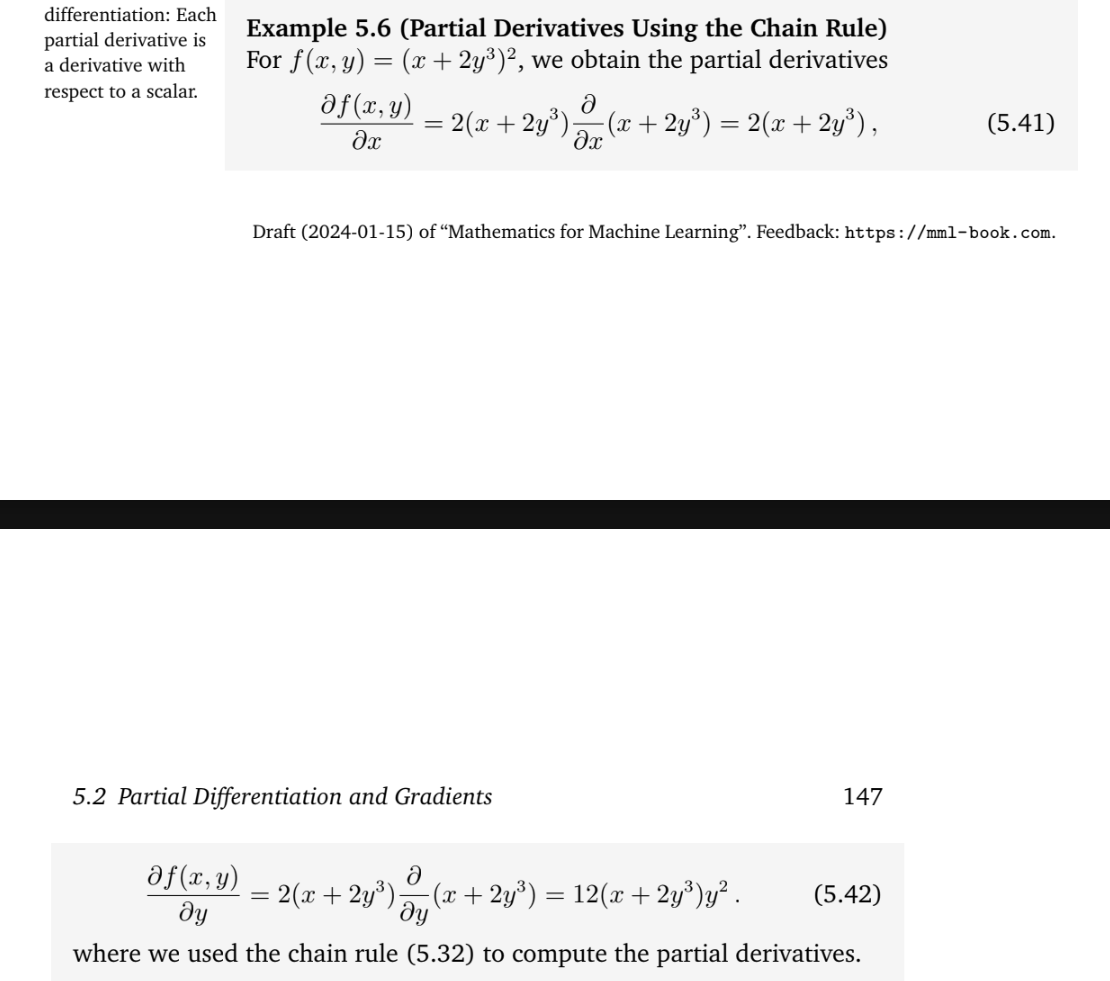

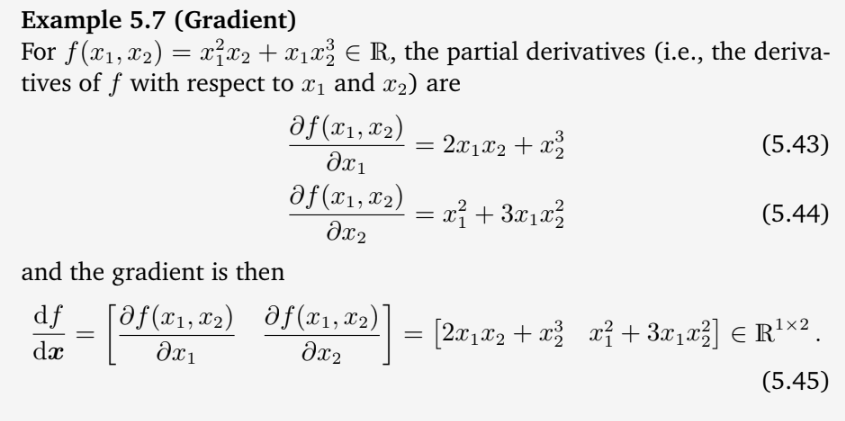

In [48]:
file_path_pic_9 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/9.png'
file_path_pic_10 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/10.png'
display(Image(filename=file_path_pic_9, width=600))
display(Image(filename=file_path_pic_10, width=600))

## Basic rules of partial differentiation

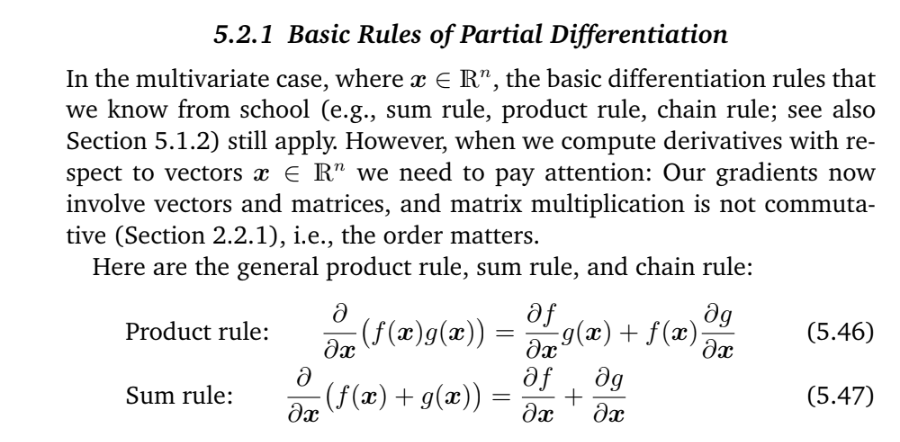

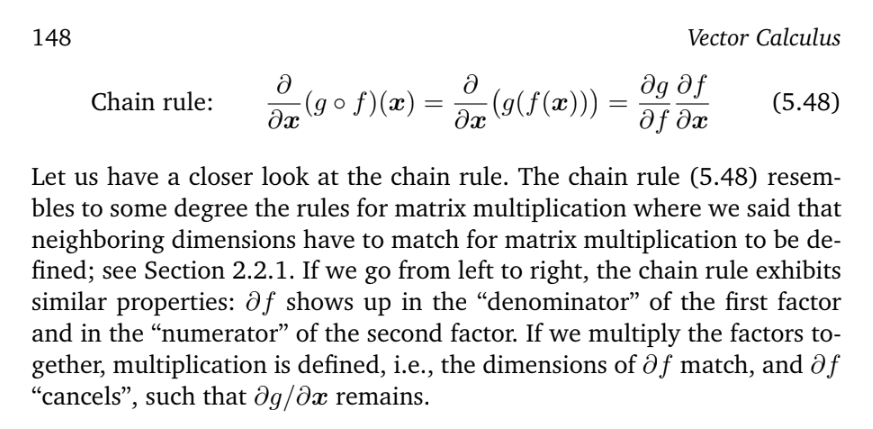

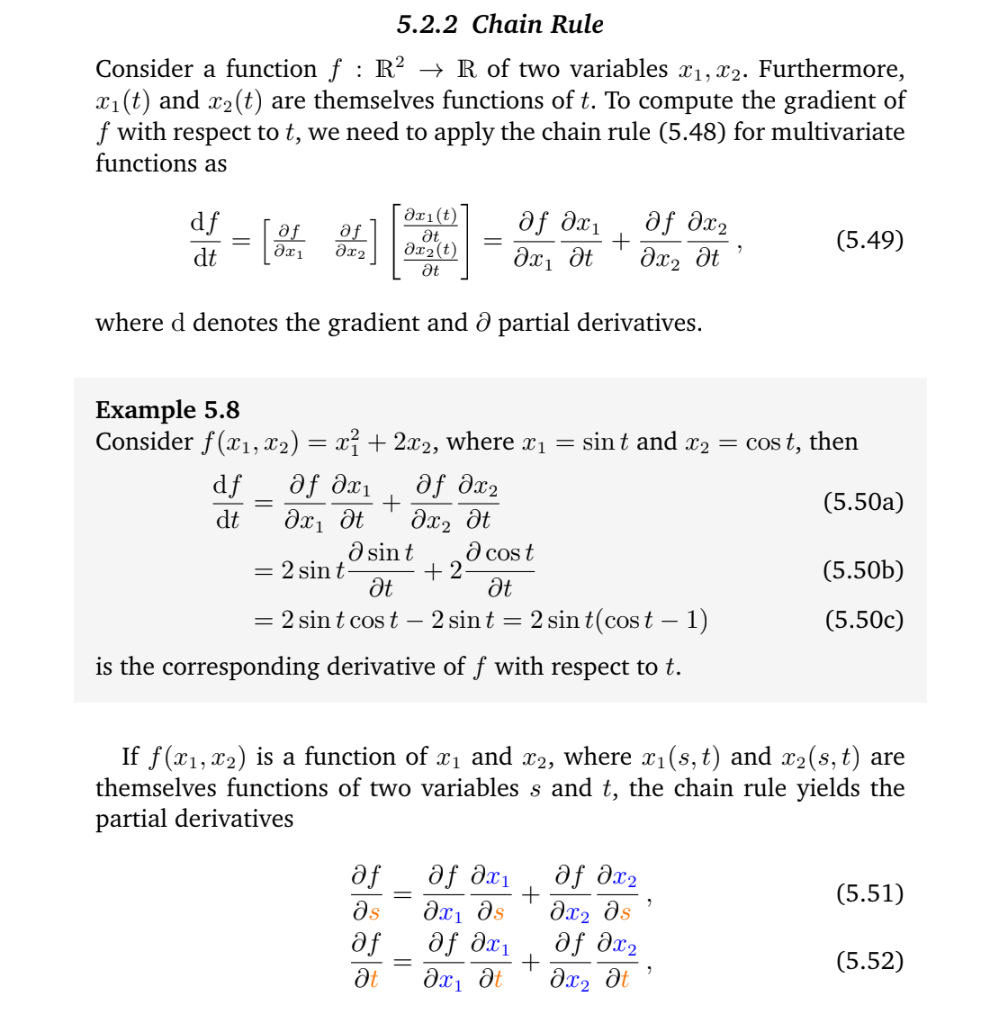

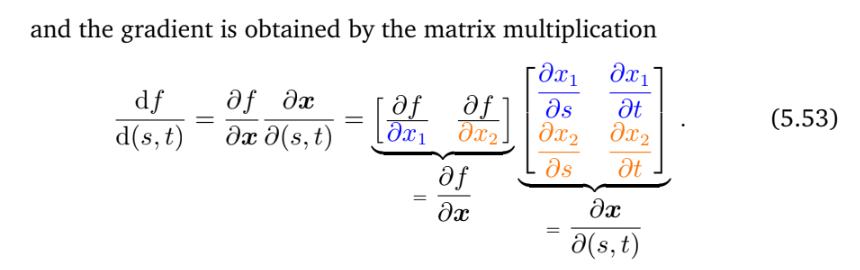

In [49]:
file_path_pic_11 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/11.png'
file_path_pic_12 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/12.png'
file_path_pic_13 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/13.png'
file_path_pic_14 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/14.png'
display(Image(filename=file_path_pic_11, width=600))
display(Image(filename=file_path_pic_12, width=600))
display(Image(filename=file_path_pic_13, width=600))
display(Image(filename=file_path_pic_14, width=600))

Quy tắc tích, áp dụng cho hàm nhận vào một ma trận:

$$
\nabla(f(X)^Tg(X)) = (\nabla f(X))g(X) + (\nabla g(X))f(X)
$$

Gradient bậc 2 của hàm số trên còn được gọi là Hessian và được định nghĩa như sau:

$$
\nabla^2 f(\mathbf{x}) \triangleq  \begin{bmatrix} \frac{\partial^2 f(\mathbf{x})}{\partial x_1^2} & \frac{\partial^2 f(\mathbf{x})}{\partial x_1 \partial x_2} & \cdots & \frac{\partial^2 f(\mathbf{x})}{\partial x_1 \partial x_n} \\ \frac{\partial^2 f(\mathbf{x})}{\partial x_2 \partial x_1} & \frac{\partial^2 f(\mathbf{x})}{\partial x_2^2} & \cdots & \frac{\partial^2 f(\mathbf{x})}{\partial x_2 \partial x_n} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial^2 f(\mathbf{x})}{\partial x_n \partial x_1} & \frac{\partial^2 f(\mathbf{x})}{\partial x_n \partial x_2} & \cdots & \frac{\partial^2 f(\mathbf{x})}{\partial x_n^2} \end{bmatrix} \in \mathbb{S}^n.
$$

Gradient của một hàm số $f(X): \mathcal{R}^{n\times m} \to \mathcal{R}$ theo ma trận $X$ được định nghĩa là

$$
\nabla f(\mathbf{X}) =  \begin{bmatrix} \frac{\partial f(\mathbf{X})}{\partial x_{11}} & \frac{\partial f(\mathbf{X})}{\partial x_{12}} & \cdots & \frac{\partial f(\mathbf{X})}{\partial x_{1m}} \\ \frac{\partial f(\mathbf{X})}{\partial x_{21}} & \frac{\partial f(\mathbf{X})}{\partial x_{22}} & \cdots & \frac{\partial f(\mathbf{X})}{\partial x_{2m}} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial f(\mathbf{X})}{\partial x_{n1}} & \frac{\partial f(\mathbf{X})}{\partial x_{n2}} & \cdots & \frac{\partial f(\mathbf{X})}{\partial x_{nm}} \end{bmatrix} \in \mathbb{R}^{n \times m}
$$

Gradient của hàm số $f: \mathcal{R}^{m\times n} \to \mathcal{R}$ là một ma trận trong $\mathcal{R}^{m \times n}$

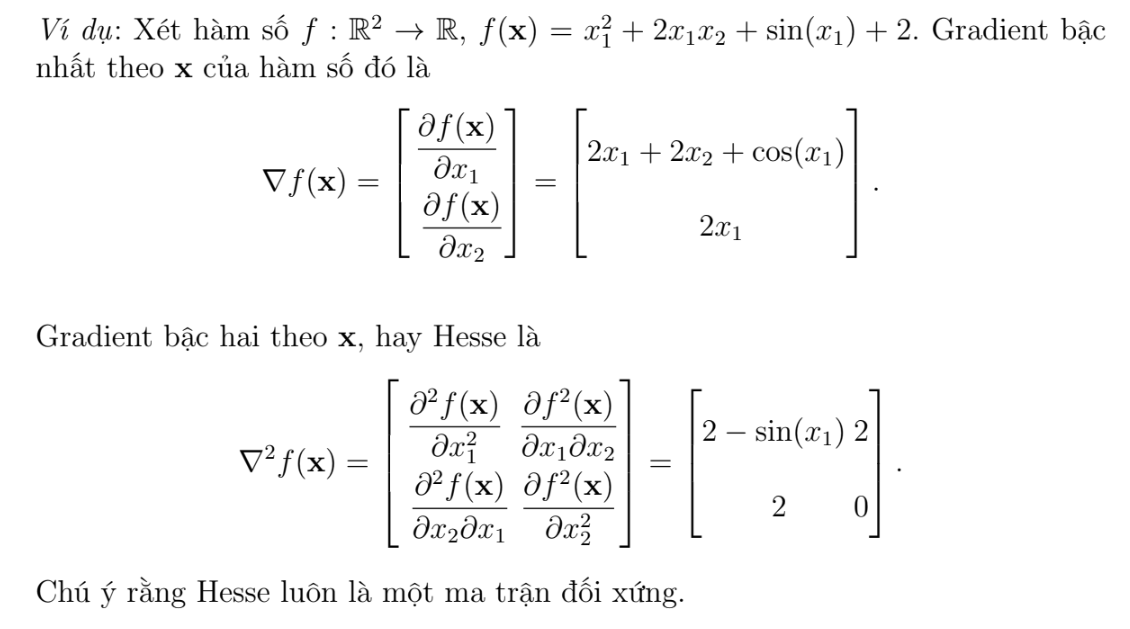

In [50]:
file_path_pic_15 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/15.png'
display(Image(filename=file_path_pic_15, width=600))

## Gradient của hàm trả về vector

Những hàm số mà đầu ra là một vector được gọi là hàm trả về vector (vector-valued function)

Xét một hàm trả về vector với đầu vào là một số thực như sau:

$$
\begin{aligned}v(x): \mathcal{R} &\to \mathcal{R}^n\end{aligned}
$$

$$
v(x) = \begin{bmatrix}v_1(x) \\ v_2(x) \\ \dots \\ v_n(x)\end{bmatrix}
$$

Gradient của hàm số này theo $x$ là một vector hàng như sau:

$$
\nabla v(x) = \begin{bmatrix} \frac{\partial v_1(x)}{\partial x} & \frac{\partial v_2(x)}{\partial x} & \frac{\partial v_3(x)}{\partial x} &\dots  & \frac{\partial v_n(x)}{\partial x}\end{bmatrix}
$$

Và gradient bậc 2 của hàm số này sẽ như sau:

$$
\nabla^2v(x) = \begin{bmatrix} \frac{\partial^2 v_1(x)}{\partial x^2} & \frac{\partial^2 v_2(x)}{\partial x^2} & \frac{\partial^2 v_3(x)}{\partial x^2} &\dots  & \frac{\partial^2 v_n(x)}{\partial x^2}\end{bmatrix}
$$

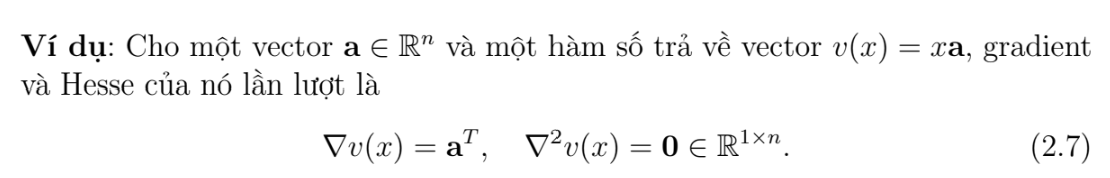

In [51]:
file_path_pic_16 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/16.png'
display(Image(filename=file_path_pic_16, width=600))

Giải:

Ta có:

$$
a = \begin{bmatrix}a_1 \\ a_2 \\ \dots \\ a_n\end{bmatrix}
$$

Áp dụng công thức tính gradient ta có:

$$
\nabla f(x) = \begin{bmatrix}\frac{\partial (xa_1)}{\partial x} & \frac{\partial (xa_2)}{\partial x} & \dots & \frac{\partial (xa_n)}{\partial x}\end{bmatrix} = \begin{bmatrix}a_1 & a_2 & \dots & a_n\end{bmatrix} = \mathbf{a}^T
$$

Dễ thấy vì hàm $f(x) = x\mathbf{a}$ là hàm bậc 1 theo $x$ nên nếu lấy gradient bậc 2, tức là đạo hàm từng phần theo $x^2$ thì kết quả là một vector hàng $\mathbf{0}$.

Xét hàm trả về một vector với đầu vào là một vector như sau:

$$
\begin{aligned}h(\mathbf{x}): \mathcal{R}^k &\to \mathcal{R}^n\end{aligned}
$$

hay

$$
h(\mathbf{x}) = \begin{bmatrix}h_1(\mathbf{x}) \\ h_2(\mathbf{x}) \\ \dots \\ h_n(\mathbf{x}) \end{bmatrix}
$$

Với các hàm $h_i(\mathbf{x}): \mathcal{R}^k \to \mathcal{R}$ là các hàm vô hướng

Gradient của hàm $h(\mathbf{x})$ được tính như sau:

$$
\nabla h(\mathbf{x}) \triangleq  \begin{bmatrix} \frac{\partial h_1(\mathbf{x})}{\partial x_1} & \frac{\partial h_2(\mathbf{x})}{\partial x_1} & \cdots & \frac{\partial h_n(\mathbf{x})}{\partial x_1} \\ \frac{\partial h_1(\mathbf{x})}{\partial x_2} & \frac{\partial h_2(\mathbf{x})}{\partial x_2} & \cdots & \frac{\partial h_n(\mathbf{x})}{\partial x_2} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial h_1(\mathbf{x})}{\partial x_k} & \frac{\partial h_2(\mathbf{x})}{\partial x_k} & \cdots & \frac{\partial h_n(\mathbf{x})}{\partial x_k} \end{bmatrix} = [\nabla h_1(\mathbf{x}) \dots \nabla h_n(\mathbf{x})] \in \mathbb{R}^{k \times n} \tag{1}
$$

Quy tắc tính có thể hiểu như sau:

- Vì các hàm $h_i(\mathbf{x})$ là các hàm vô hướng nên gradient của hàm này trả về một vector cột có đạo hàm riêng theo từng thành phần, xếp các vector cột này lại thành một ma trận ta được ma trận gradient của hàm $h(\mathbf{x})$.

Gradient của hàm số $g: \mathcal{R}^m \to \mathcal{R}^n$ là một ma trận thuộc $\mathcal{R}^{m\times n}$

Phần này cũng cần chú ý về ký hiệu toán học như sau:

Trong sách [1] sẽ trình bày theo chuẩn toán học như sau:

Cho hàm số trả về vector với đầu vào là một vector $\mathbf{f}: \mathcal{R}^n \to \mathcal{R}^m$ với vector $\mathbf{x} = \begin{bmatrix}x_1 & x_2 & \dots & x_n\end{bmatrix}^T \in \mathcal{R}^n$

$$
f(\mathbf{x}) = \begin{bmatrix}f_1(\mathbf{x}) \\ \dots \\ f_m(\mathbf{x})\end{bmatrix} \in \mathcal{R}^m
$$

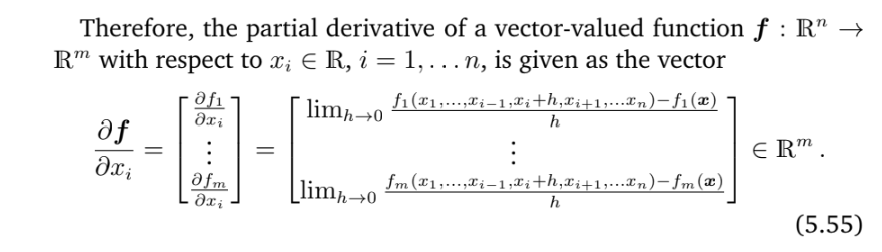

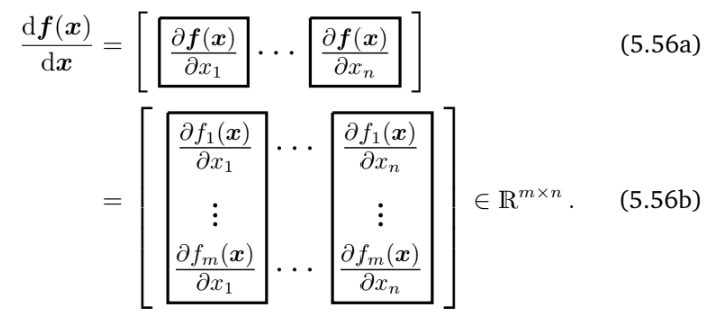

In [52]:
file_path_pic_17 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/17.png'
file_path_pic_18 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/18.png'
display(Image(filename = file_path_pic_17, width=600))
display(Image(filename=file_path_pic_18, width=600))

- Tới đây thì ta thấy có chút sự khác biệt là ma trận (5.56b) trong sách [1] là chuyển vị của ma trận tương tự trong sách [2]. Sự khác biệt này dẫn tới hệ quả trong ma trận Jacobian được trình bày bên dưới

## Jacobian

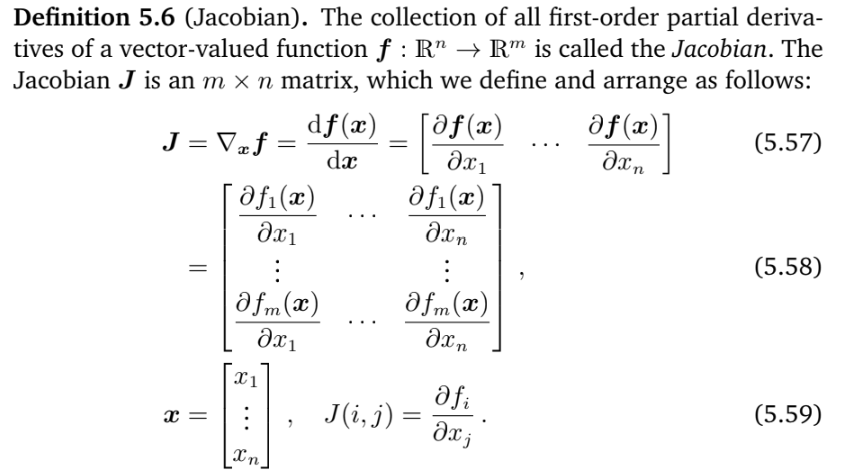

In [53]:
file_path_pic_19 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/19.png'
display(Image(filename=file_path_pic_19, width=600))

Dạng ma trận được trình bày phía trên (trong sách [1]) có định dạng là “numerator layout” (chuẩn toán học), nhưng vẫn còn một dạng trình bày nữa được sử dụng nhiều trong máy học và học sâu là chuyển vị của ma trận numerator layout, được gọi là denominator layout (là ma trận (1) phía trên).

## Kết quả của một số gradient thường gặp

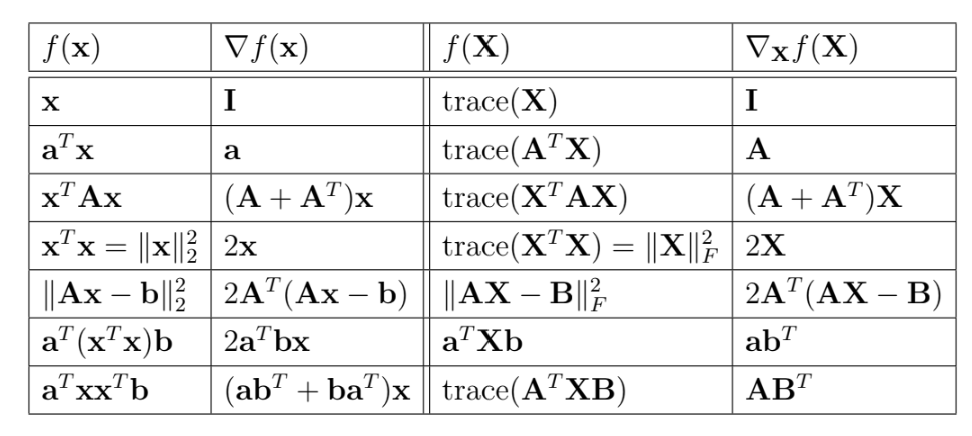

In [54]:
file_path_pic_20 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/20.png'
display(Image(filename=file_path_pic_20, width=600))

## Xấp xỉ Gradient - Kiểm tra gradient
Trong phần này thì mình sẽ học về phương pháp tính xấp xỉ Gradient

Trong thực tế việc tính Gradient của hàm nhiều biến thông thường khá phức tạp và dễ có sai xót. Trong thực nghiệm thì chúng ta có phương pháp để kiểm tra liệu Gradient có được tính đúng hay không.

## Xấp xỉ đạo hàm của hàm một biến
Ta có định nghĩa của đạo hàm của hàm một biến như sau:
$$
f'(x) = \lim_{\epsilon \to 0} \frac{f(x+\epsilon) - f(x)}{\epsilon}
$$

Khi cài đặt bằng công thức này, ta có thể chọn $\epsilon$ rất nhỏ khoảng $10^{-6}$, thì ta có phép xấp xỉ sau:
$$
f'(x) \approx \lim_{\epsilon \to 0} \frac{f(x+\epsilon) - f(x)}{\epsilon}
$$

Tuy nhiên, trên thực tế chúng ta lại sử dụng công thức xấp xỉ đạo hàm hai phía sau đây hơn:
$$
f'(x) \approx \lim_{\epsilon \to 0} \frac{f(x+\epsilon) - f(x - \epsilon)}{2\epsilon}
$$

Cách tính trên được gọi là numerical gradient và chúng ta có giải thích tính hiệu quả của numerical gradient cho việc xấp xỉ đạo hàm sau đây:
### Chứng minh hình học



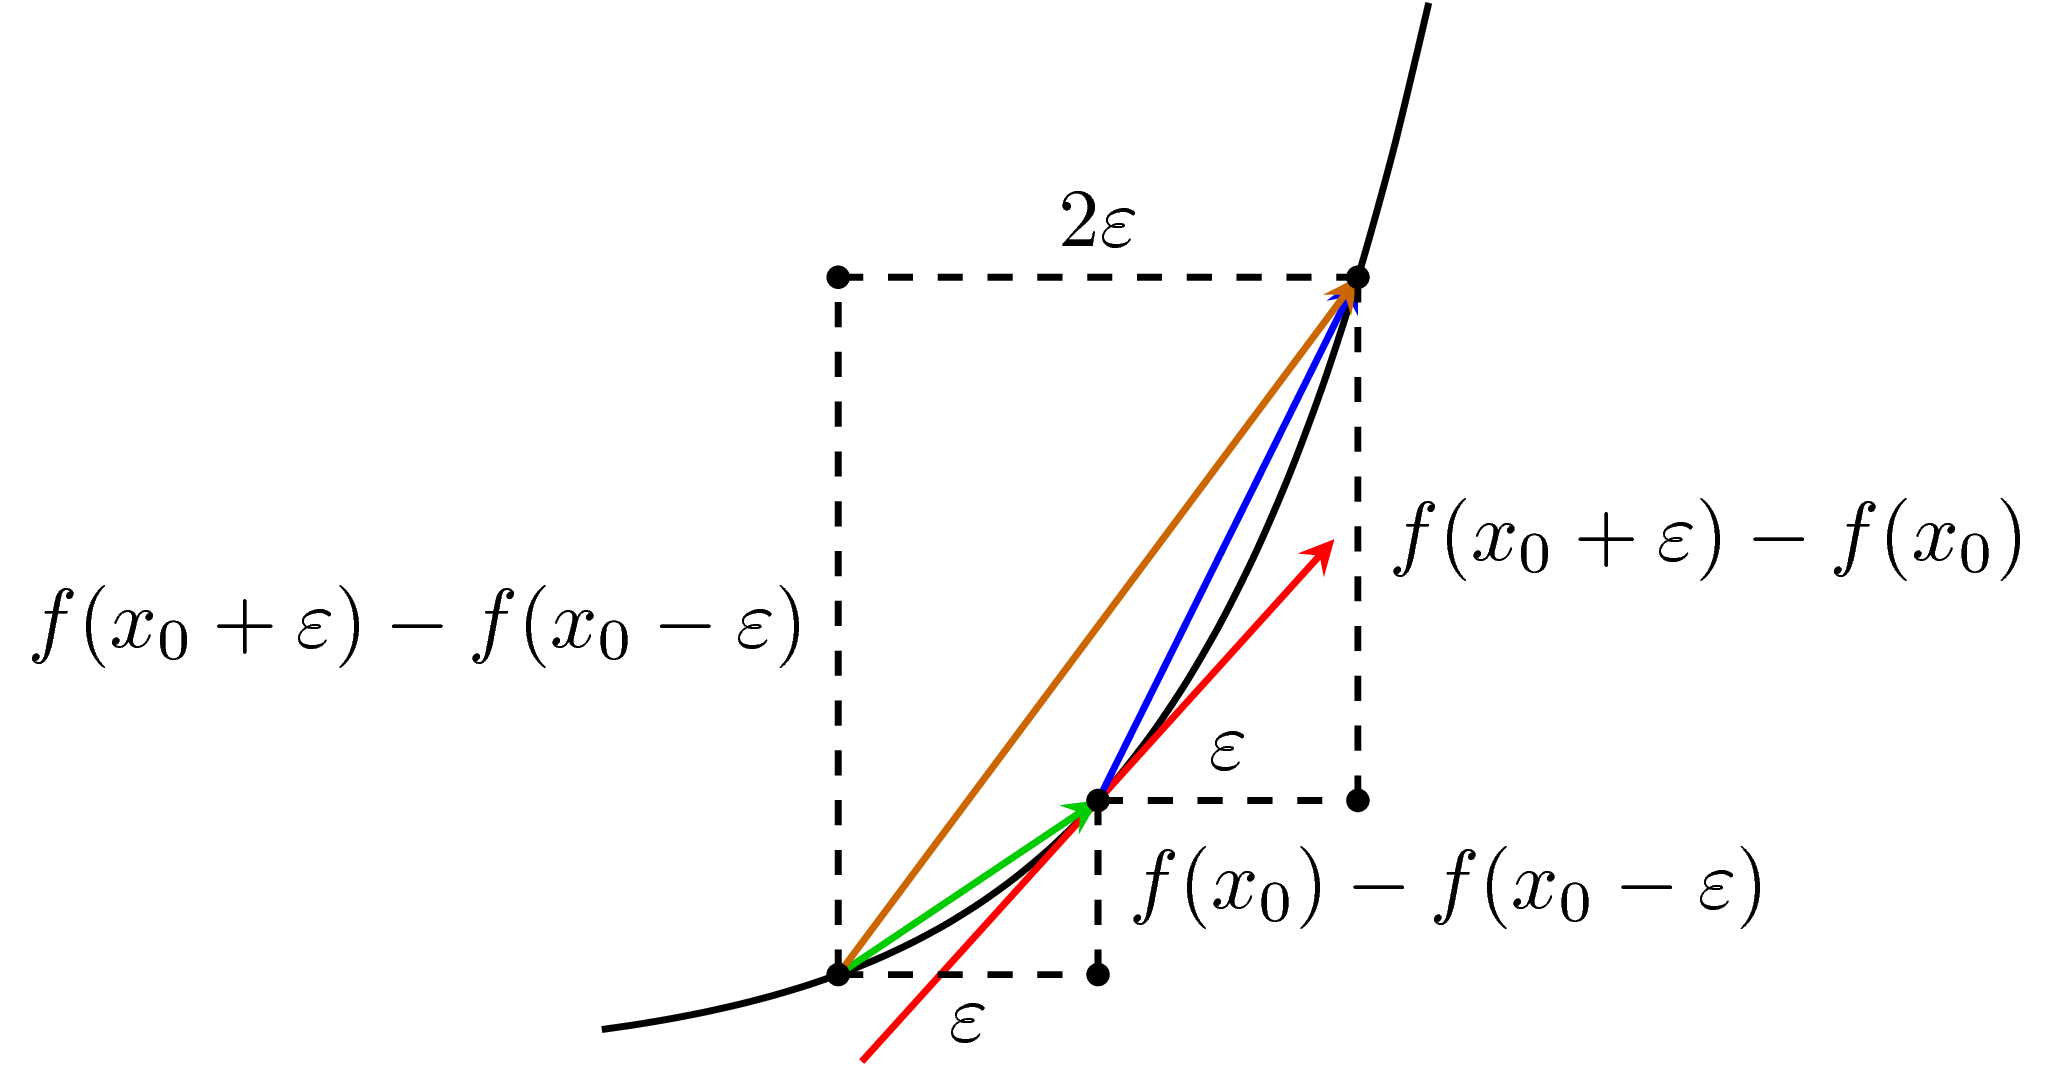

In [55]:
file_path_pic_21 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/21.png'
display(Image(filename=file_path_pic_21, width=600))

Trong hình, vector màu đỏ là đạo hàm *chính xác* của hàm số tại điểm có hoành độ bằng $x_0$. Vector màu xanh lam thể hiện cách xấp xỉ đạo hàm phía phải. Vector màu xanh lục thể hiện cách xấp xỉ đạo hàm phía trái. Vector màu nâu thể hiện cách xấp xỉ đạo hàm hai phía. Trong ba vector xấp xỉ đó, vector xấp xỉ hai phía màu nâu là gần với vector đỏ nhất nếu xét theo hướng.

Sự khác biệt giữa các cách xấp xỉ còn lớn hơn nữa nếu tại điểm $x$, hàm số bị *bẻ cong* mạnh hơn. Khi đó, xấp xỉ trái và phải sẽ khác nhau rất nhiều. Xấp xỉ hai bên sẽ *ổn định* hơn.

### Chứng minh Giải tích
Ý tưởng là sử dụng chuỗi Taylor  
Với $\epsilon$ rất nhỏ, ta có xấp xỉ sau đây:

$$
f(x + \varepsilon) \approx f(x) + f'(x)\varepsilon + \frac{f''(x)}{2}\varepsilon^{2} + \dots
$$

Và:

$$
f(x- \varepsilon) \approx f(x) - f'(x)\varepsilon + \frac{f''(x)}{2}\varepsilon^{2} - \dots
$$

Từ đây, ta có:

$$
\frac{f(x + \varepsilon) - f(x)}{\varepsilon} \approx f'(x) + \frac{f''(x)}{2}\varepsilon + \dots = f'(x) + O(\varepsilon) \tag{3}
$$

$$
\frac{f(x + \varepsilon) - f(x - \varepsilon)}{2\varepsilon} \approx f'(x) + \frac{f^{(3)}(x)}{6}\varepsilon^{2} + \dots = f'(x) + O(\varepsilon^{2}) \tag{4}
$$

Từ đó, nếu xấp xỉ đạo hàm bằng công thức (3) (xấp xỉ đạo hàm phải), sai số sẽ là $O(\varepsilon)$. Trong khi đó, nếu xấp xỉ đạo hàm bằng công thức (4) (xấp xỉ đạo hàm hai phía), sai số là $O(\varepsilon^{2}) << O(\varepsilon)$ nếu $\varepsilon$ nhỏ.

Cả hai cách giải thích trên đây đều cho chúng ta thấy rằng, xấp xỉ đạo hàm hai phía là xấp xỉ ổn định hơn.

## Xấp xỉ đạo hàm của hàm nhiều biến
Với hàm nhiều biến, công thức (4) được áp dụng cho từng biến trong khi các biến khác là cố định.  

Cách tính gradient xấp xỉ hai phía thường cho giá trị khá chính xác. Tuy nhiên,
cách này không được sử dụng để tính gradient vì độ phức tạp quá cao so với cách
tính trực tiếp. Tại mỗi thành phần, ta cần tính giá trị của hàm số tại phía trái
và phía phải. Việc làm này không khả thi với các ma trận lớn. Khi so sánh đạo
hàm xấp xỉ với gradient tính theo công thức, người ta thường giảm số chiều dữ
liệu và giảm số điểm dữ liệu để thuận tiện cho tính toán. Nếu gradient tính được
là chính xác, nó sẽ rất gần với gradient xấp xỉ này.

Đoạn code sau đây sẽ kiểm tra gradient của một hàm số khả vi $f: \mathcal{R}^{m \times n} \to \mathcal{R}$

Hàm `check_gradient` là hàm kiểm tra đạo hàm 2 phía, hàm `fn(X)` tính giá trị của hàm số tại $X$, hàm `grad(X)` sẽ tính gradient của `fn(X)`.

Giả sử ta muốn tính toán xấp xỉ gradient cho 2 hàm số sau:
$f(\mathbf{X}) = \operatorname{trace}(A\mathbf{X})$ và hàm số $f(x) = \mathbf{x}^TA\mathbf{x}$

In [56]:
def check_grad(f, grad, X, eps=1e-6):
  X_flat = X.reshape(-1)
  shape_X = X.shape
  numerical_gradient = np.zeros_like(X)
  gradient_flat = np.zeros_like(X_flat)
  nb_of_elements = X_flat.shape[0]

  for i in range(nb_of_elements):
    X_plus = X_flat.copy()
    X_negative = X_flat.copy()
    X_plus[i] += eps
    X_negative[i] -= eps
    X_plus = X_plus.reshape(shape_X)
    X_negative = X_negative.reshape(shape_X)
    gradient_flat[i] = (f(X_plus) - f(X_negative)) / (2*eps)

  numerical_gradient = gradient_flat.reshape(shape_X)
  difference = np.linalg.norm(numerical_gradient - grad(X))
  print(f'The difference should be small: {difference}')

In [57]:
np.random.seed(42)

In [58]:
# Initialize matrix A, X randomly
m, n = 10, 20
A = np.random.rand(m, n)
X = np.random.rand(n, m)

# check if grad(trace(A*X)) == A^T
def f1(X):
  return np.trace(np.dot(A, X))
def grad1(X):
  return A.T
check_grad(f1, grad1, X)

The difference should be small: 2.405960065979526e-08


In [59]:
A_new = np.random.rand(m, m)
x = np.random.rand(m, 1)
# check if grad(x^T*A*x) == (A + A^T)*x
def f2(x):
  return (x.T @ A_new @ x).item()
def grad2(x):
  return (A_new + A_new.T) @ x
check_grad(f2, grad2, x)

The difference should be small: 6.581628037933867e-09


Đoạn code sau đây sẽ kiểm tra xấp xỉ đạo hàm cho hàm số trả về một vector/ma trận $f: \mathcal{R}^n \to \mathcal{R}^m$  

Ta biết được kết quả Gradient của hàm $f$ là một ma trận $\mathcal{R}^{m\times n}$

In [60]:
def check_grad_JacobianMatrix(f, grad, X, eps=1e-6):
  X_flat = X.reshape(-1)
  shape_X = X.shape
  Y_sample = f(X)
  M = len(Y_sample.reshape(-1)) # use to get M, not use in algorithm
  N = X_flat.shape[0]

  numerical_jacobian = np.zeros((M, N))

  for i in range(N):
    X_plus = X_flat.copy()
    X_negative = X_flat.copy()

    X_plus[i] += eps
    X_negative[i] -= eps

    X_plus = X_plus.reshape(shape_X)
    X_negative = X_negative.reshape(shape_X)

    Y_plus, Y_negative = f(X_plus).reshape(-1), f(X_negative).reshape(-1)

    numerical_jacobian[:, i] = (Y_plus - Y_negative) / (2*eps)

  analytical_jacobian = grad(X)

  if analytical_jacobian.shape != numerical_jacobian.shape:
    analytical_jacobian = analytical_jacobian.reshape((M, N))

  difference = np.linalg.norm(numerical_jacobian - analytical_jacobian)
  print(f'The difference should be small: {difference}')

Tính xấp xỉ cho 2 hàm số $f(x) = Wx$ và $f(\mathbf{x}) = \left \|A\mathbf{x} - b \right\|_2^2$

In [61]:
# initialize W randomly
M, N = 10, 20
W = np.random.rand(M, N)
x3 = np.random.rand(N, 1)

# check if grad(Wx) == W

def f3(x3):
  return W @ x3
def grad3(x3):
  return W

check_grad_JacobianMatrix(f3, grad3, x3)

The difference should be small: 3.1164097431284236e-09


In [62]:
# initialize A randomly
A = np.random.rand(M, N)
b = np.random.rand(M,1)
x_ax_b = np.random.rand(N, 1)

# check if grad(||Ax - b||_2^2) == 2A^T(Ax - b)
def f4(x_ax_b):
  return np.array([np.linalg.norm(A @ x_ax_b - b, ord=2) ** 2])
def grad4(a_ax_b):
  return 2 * A.T @ (A @ x_ax_b - b)

check_grad_JacobianMatrix(f4, grad4, x_ax_b)

The difference should be small: 1.2947821638556443e-07


Qua các ví dụ trên, có thể thấy, trong thực nghiệm ta có thể thu được kết quả tính Gradient dựa vào phương pháp xấp xỉ đạo hàm 2 phía nói trên

Tuy là hiệu quả, nhưng nếu sử dụng thì độ phức tạp lại quá cao so với cách tính trực tiếp. Tại mỗi thành phần thì phải tính đạo hàm tại 2 phía và chúng không hiệu quả với các ma trận dữ liệu lớn.

Dẫn đến khi so sánh đạo hàm xấp xỉ với Gradient tính theo công thức, người ta thường giảm số chiều dữ liệu để thuận tiện cho việc tính toán. Nếu gradient tính được
là chính xác, nó sẽ rất gần với gradient xấp xỉ này.

## Chain rule example

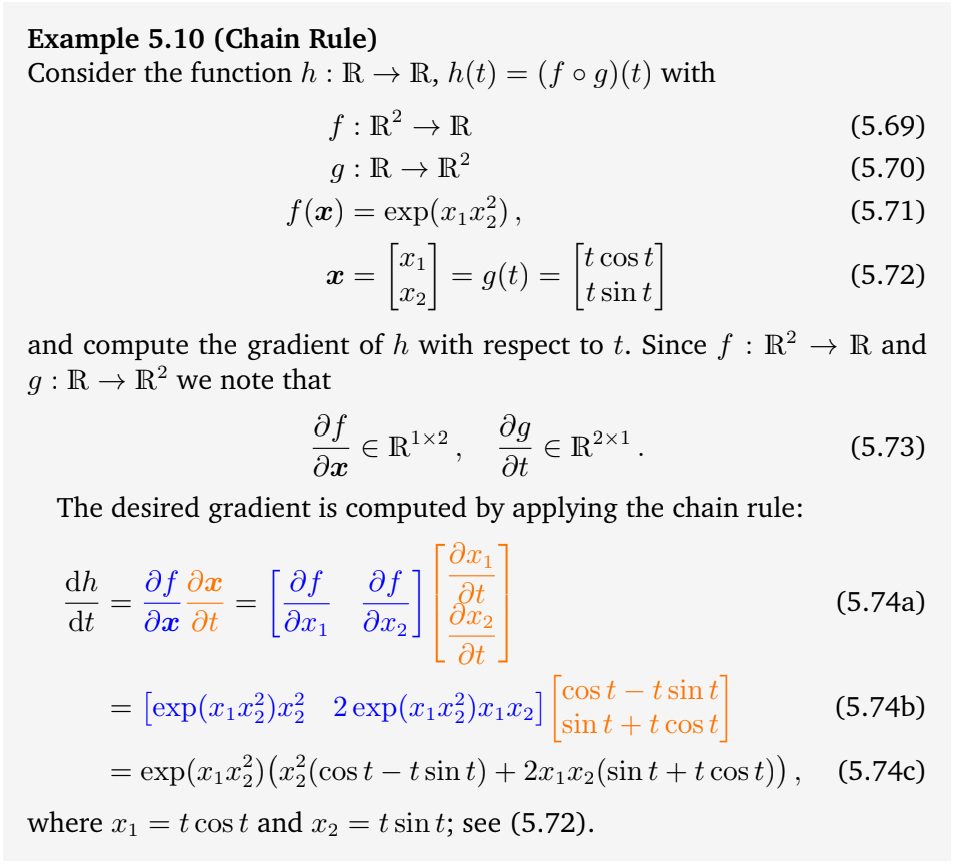

In [63]:
file_path_pic_22 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/22.png'
display(Image(filename=file_path_pic_22, width=600))

## Gradient of matrices

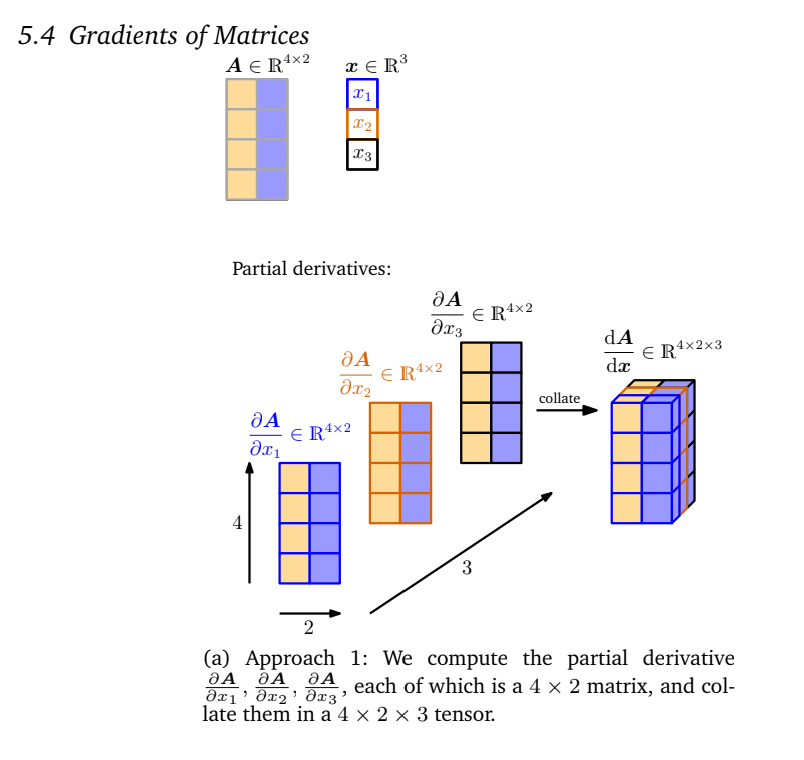

In [64]:
file_path_pic_23 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/23.png'
display(Image(filename=file_path_pic_23, width=600))

Đại ý trong bức ảnh nói về gradient của một matrix theo vector $\mathbf{x}$ với hướng tiếp cận số 1, cứ sử dụng nguyên lý cơ bản là đạo hàm theo từng thành phần trong vector, có 3 thành phần là $x_1, x_2, x_3$ → Tạo thành tensor $4 \times 2 \times 3$.

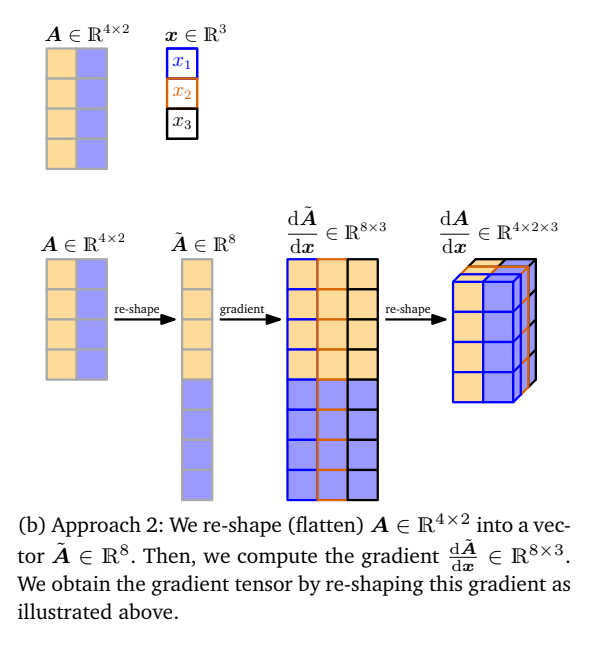

In [65]:
file_path_pic_24 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/24.png'
display(Image(filename=file_path_pic_24, width=600))

Ở đây sử dụng cách tiếp cận thứ 2 bằng cách làm phẳng ma trận $\mathbf{A}$ và sau đó ghép nối đạo hàm từng thành phần lại thành một ma trận $\mathcal{R}^{8 \times 3}$rồi reshape về lại dạng ban đầu để được tensor $4 \times 2 \times 3$

Tensor = multidimensional array

We can think of this tensor as a multidimensional array that collects partial derivatives.

For example, if we compute the gradient of an $m × n$ matrix $A$ with respect to a $p × q$ matrix $B$, the resulting Jacobian would be $(m×n)×(p×q)$, i.e., a four-dimensional tensor $J$, whose entries are given as $J_{ijkl} = \frac{\partial A_{ij}}{\partial Bkl}$.

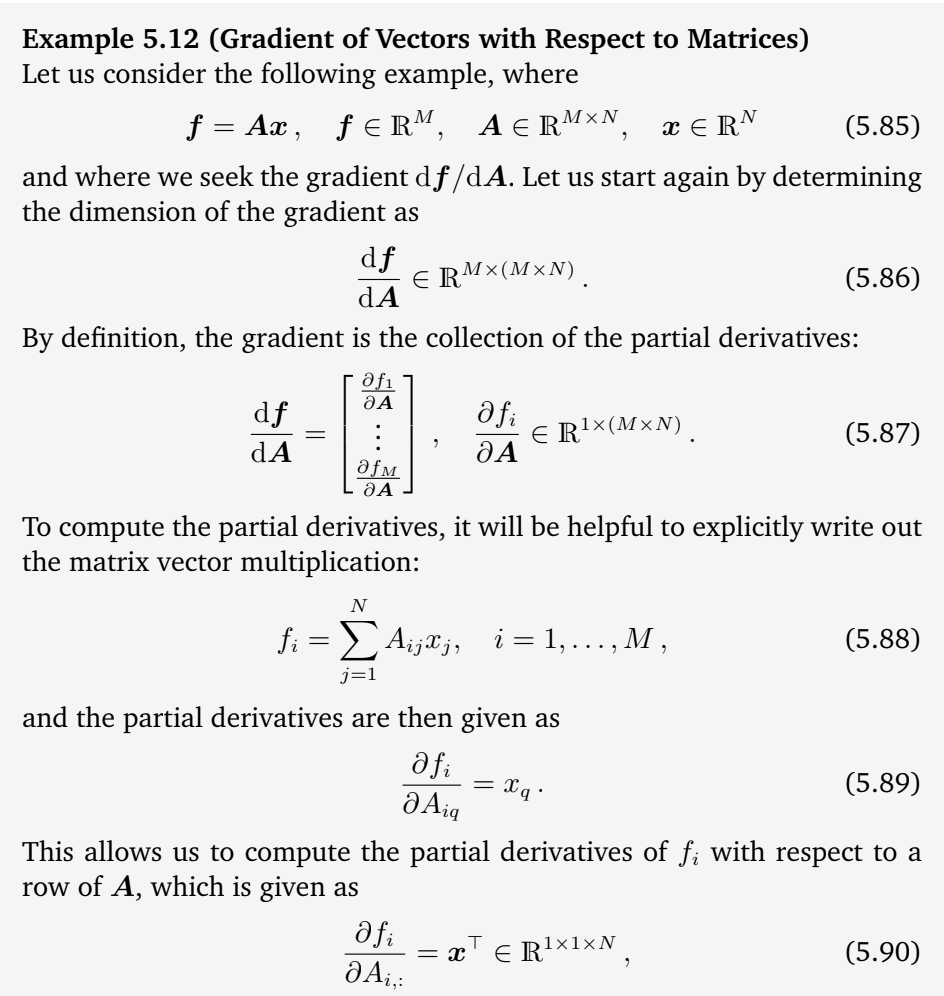

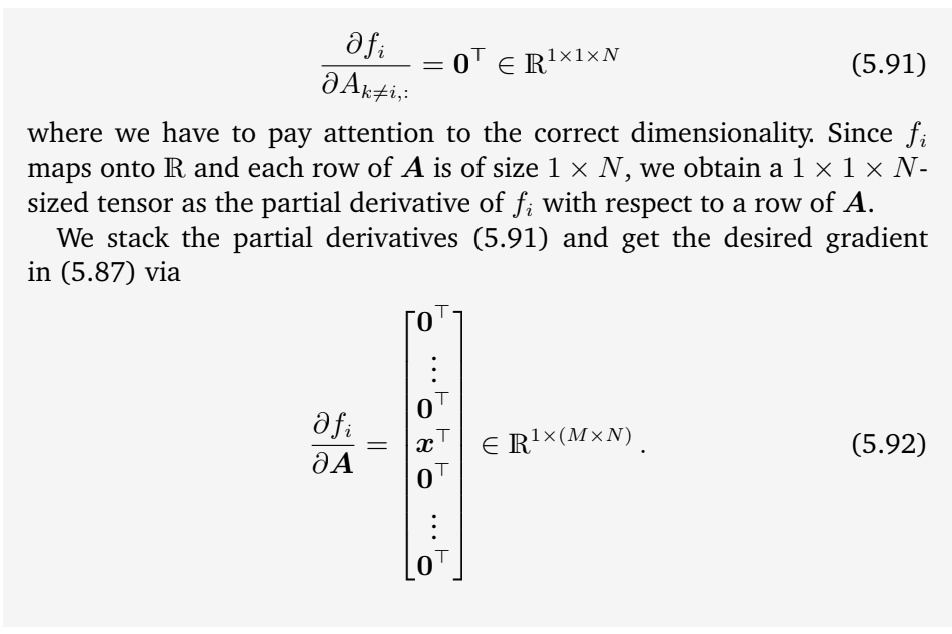

In [68]:
file_pic_path_25 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/25.png'
file_path_pic_26 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/26.png'
display(Image(filename=file_pic_path_25, width=600))
display(Image(filename=file_path_pic_26, width=600))

Đoạn trên trình bày dễ hiểu về quy tắc tính gradient của ma trận (nhớ lại theo sách [1] thì tác giả quy ước đạo hàm từng phần của một hàm vô hướng là một vector hàng hay còn gọi là jacobian và $f$ là hàm trả về một vector nên ta sắp theo cột, hơi ngược lại với quy ước của sách [2]).

Vậy theo lý thuyết thì tensor mới được tạo thành từ phép gradient của hàm $f$ có dimension là $M$ theo ma trận $A$ có dimension là $M \times N$ này là

$$
\frac{df}{dA} = \begin{bmatrix}\frac{\partial f_1}{\partial A} \\  \dots \\ \frac{\partial f_M}{\partial A}\end{bmatrix} \in \mathcal{R}^{M \times (M \times N)}; \frac{\partial f_i}{\partial A} \in \mathcal{R}^{1 \times (M \times N)}
$$

Các phép tính lần lượt các đạo hàm từng phần tương tự như phép tính gradient của hàm $f(\mathbf{x}) = A\mathbf{x}$

Ở đoạn cuối thì cứ mỗi một thành phần $\frac{\partial f_i}{\partial A}$ sẽ có dạng của (5.92), vậy thì $M$ thành phần ban đầu xếp lại theo chiều thứ 3 là tạo thành một tensor như trên lý thuyết.

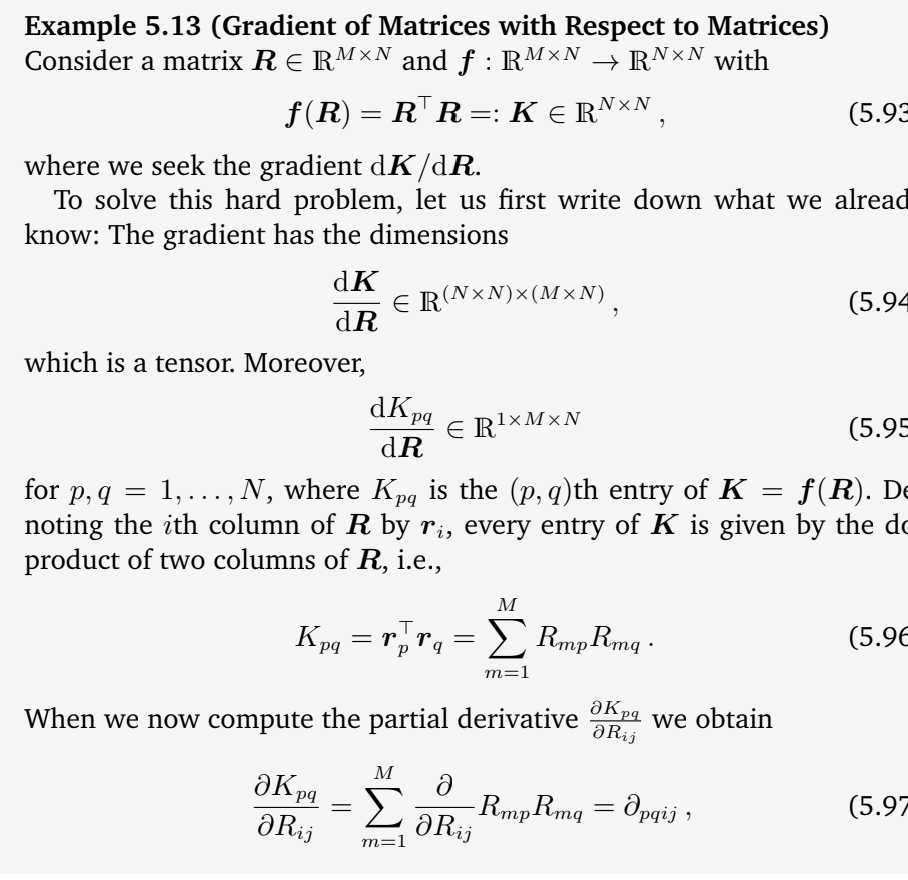

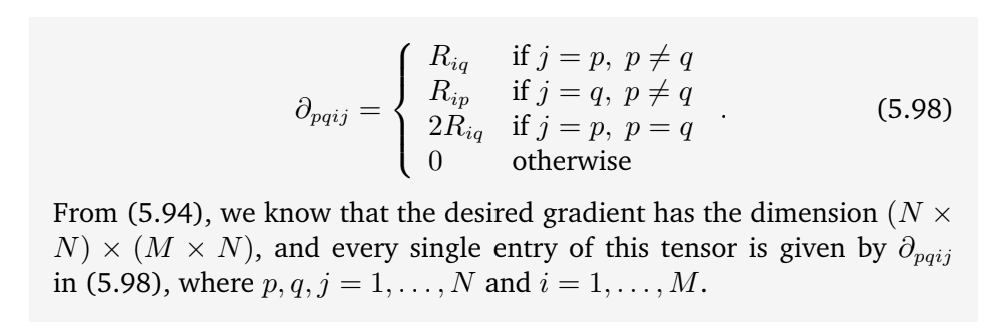

In [69]:
file_path_pic_27 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/27.png'
file_path_pic_28 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/28.png'
display(Image(filename=file_path_pic_27, width=600))
display(Image(filename=file_path_pic_28, width=600))

Giải thích một chút về kết quả thu được ở 5.98 như sau:

Từ 5.97 ta có:

$$
\frac{\partial K_{pq}}{\partial R_{ij}} = \sum_{m=1}^M \frac{\partial}{\partial R_{ij}}R_{mp}R_{mq} = \frac{\partial (R_{ip}R_{iq})}{\partial R_{ij}} = \frac{\partial R_{ip}}{\partial R_{ij}}R_{iq} + R_{ip}\frac{\partial R_{iq}}{\partial R_{ij}}
$$

Vì các phần tử ở vị trí $m \neq i$ đều có đạo hàm = 0 → Chỉ còn lại $m= i$

Sau đó ta lần lượt xét các trường hợp:

1. Nếu $p = j$ và $p \neq q$ $\Rightarrow \frac{\partial R_{ip}}{\partial R_{ij}} = 1; \frac{\partial R_{iq}}{\partial R_{ij}} = 0$, do đó thì ta thu được kết quả:
    
    $$
    \frac{\partial K_{pq}}{\partial R_{ij}} = R_{iq}
    $$
    
2. Nếu $p \neq j$ và $q = j$ $\Rightarrow \frac{\partial R_{ip}}{\partial R_{ij}} = 0; \frac{\partial R_{iq}}{\partial R_{ij}} = 1$, do đó thì ta có kết quả:
    
    $$
    \frac{\partial K_{pq}}{\partial R_{ij}} = R_{ip}
    $$
    
3. Nếu $p = j$ và $p = q$ $\Rightarrow \frac{\partial R_{ip}}{\partial R_{ij}} = 1; \frac{\partial R_{iq}}{\partial R_{ij}} = 1$, do đó thì kết quả là:
    
    $$
    \frac{\partial K_{pq}}{\partial R_{ij}} = R_{iq} + R_{ip} = 2R_{iq}
    $$
    
4. Các điều kiện còn lại  $\Rightarrow \frac{\partial R_{ip}}{\partial R_{ij}} = 0; \frac{\partial R_{iq}}{\partial R_{ij}} = 0$, do đó thì kết quả là:
  $$
    \frac{\partial K_{pq}}{\partial R_{ij}} = 0
  $$

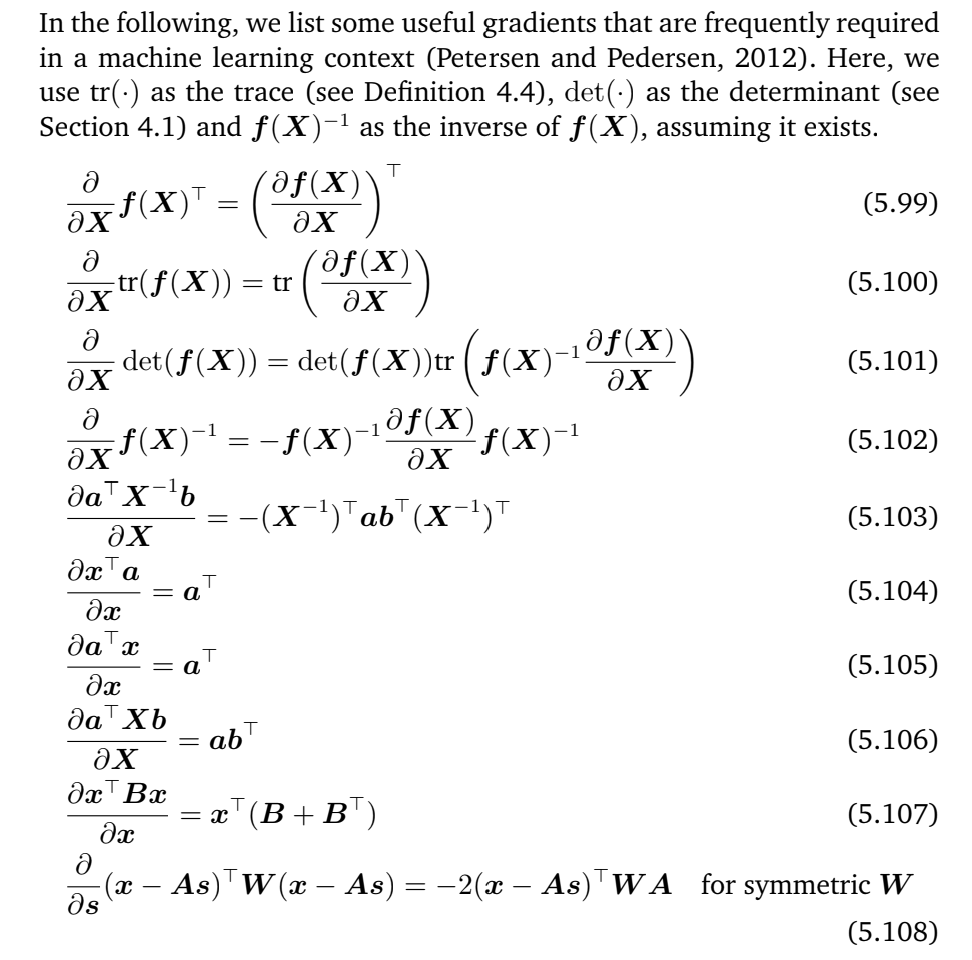

In [70]:
file_path_pic_29 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/29.png'
display(Image(filename=file_path_pic_29, width=600))

# Backpropagation and Automatic Differentiation

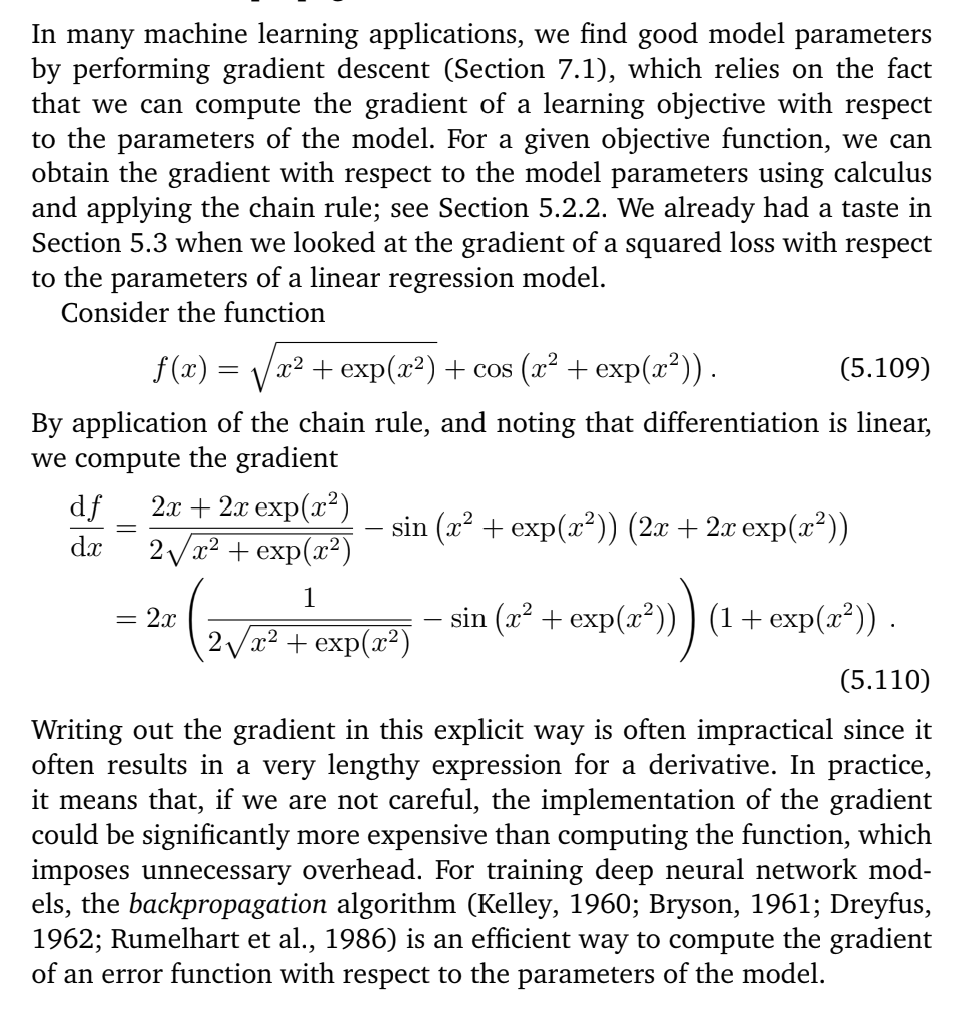

In [71]:
file_path_pic_30 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/30.png'
display(Image(filename=file_path_pic_30, width=600))

Trong đoạn trên thì tác giả nói về quy tắc tính toán đạo hàm với các hàm phức tạp hơn bên trong (hàm hợp). Và tác giả nói là impractical. Vì vậy trong thực tế, đối với DNN thì người ta sử dụng thuật toán backpropagation nhiều hơn là tính toán đạo hàm của hàm hợp thông thường - vốn dễ gây lỗi và dài dòng

### Gradient in a deep network

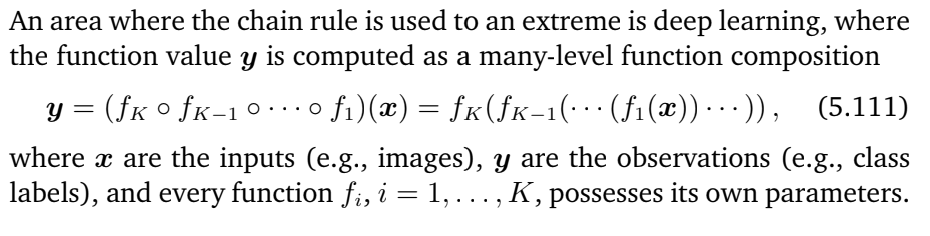

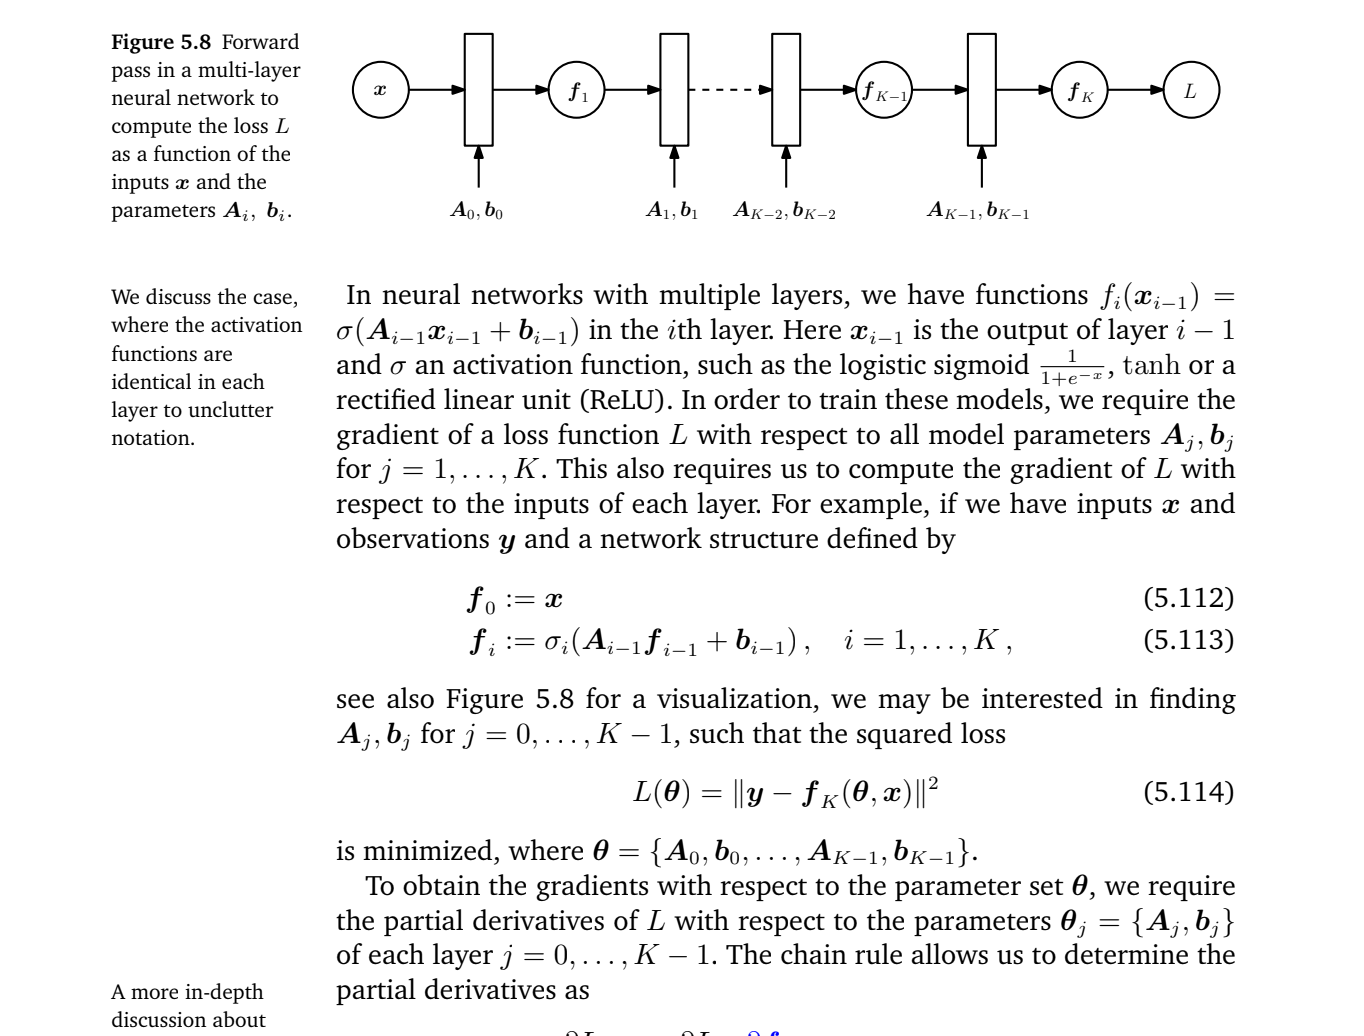

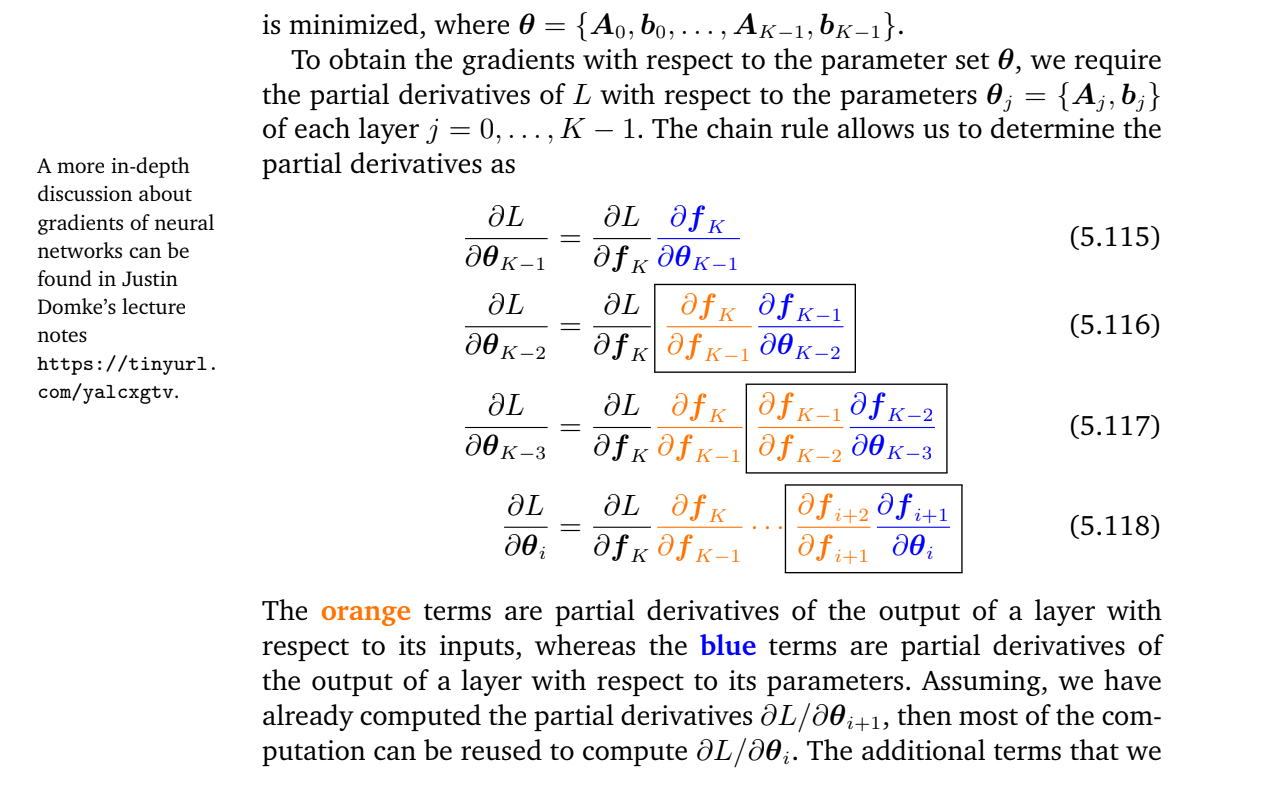

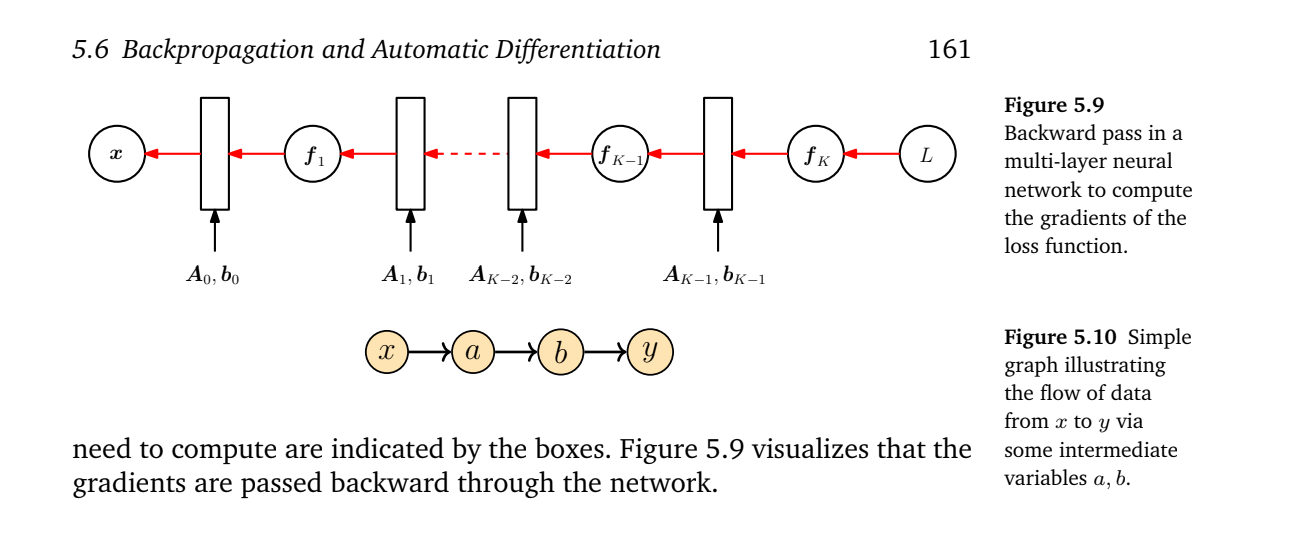

In [72]:
file_path_pic_31 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/31.png'
file_path_pic_32 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/32.png'
file_path_pic_33 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/33.png'
file_path_pic_34 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/34.png'
display(Image(filename=file_path_pic_31, width=600))
display(Image(filename=file_path_pic_32, width=600))
display(Image(filename=file_path_pic_33, width=600))
display(Image(filename=file_path_pic_34, width=600))

Mạng học sâu xử lý đầu vào $x$ thành đầu ra $y$ thông qua một chuỗi các hàm số nối tiếp nhau: $y = (f_K \circ f_{K-1} \circ \dots \circ f_1)(x)$. Tại mỗi tầng thứ $i$, hàm $f_i$ sẽ thực hiện biến đổi dữ liệu dựa trên tập tham số cục bộ $\theta = \{A, b\}$ và một hàm kích hoạt $\sigma$.

**Khai triển bằng quy tắc chuỗi (Chain Rule):** Thay vì tính toán đạo hàm trực tiếp rất phức tạp, hệ thống sẽ tính dần các đạo hàm riêng từ tầng cuối cùng (tầng $K$) ngược trở về đầu mạng. Trong các phương trình (5.115) đến (5.118), quy tắc chuỗi phân rã việc tính gradient thành tích của hai thành phần chính:   

- **Các số hạng màu xanh dương:** Là đạo hàm đầu ra của một tầng đối với các tham số của tầng đó.
- **Các số hạng màu cam:** Là đạo hàm đầu ra của một tầng đối với dữ liệu đầu vào của nó. Thành phần này đóng vai trò truyền tín hiệu lỗi tiếp tục lùi về các tầng trước đó.

Điểm tối ưu nhất của backpropagation nằm ở việc tận dụng lại kết quả. Giả sử mạng đã tính xong đạo hàm riêng ở tầng $i+1$ là $\frac{\partial L}{\partial \theta_{i+1}}$, thì nó có thể tái sử dụng gần như toàn bộ phép tính này để tìm $\frac{\partial L}{\partial \theta_i}$. Thuật toán chỉ cần tính thêm các số hạng phụ và nhân dồn chúng vào chuỗi gradient lúc đầu (biểu diễn bằng các mũi tên màu đỏ).

Một ví dụ nhỏ về backpropagation (chưa học, revisit sau)

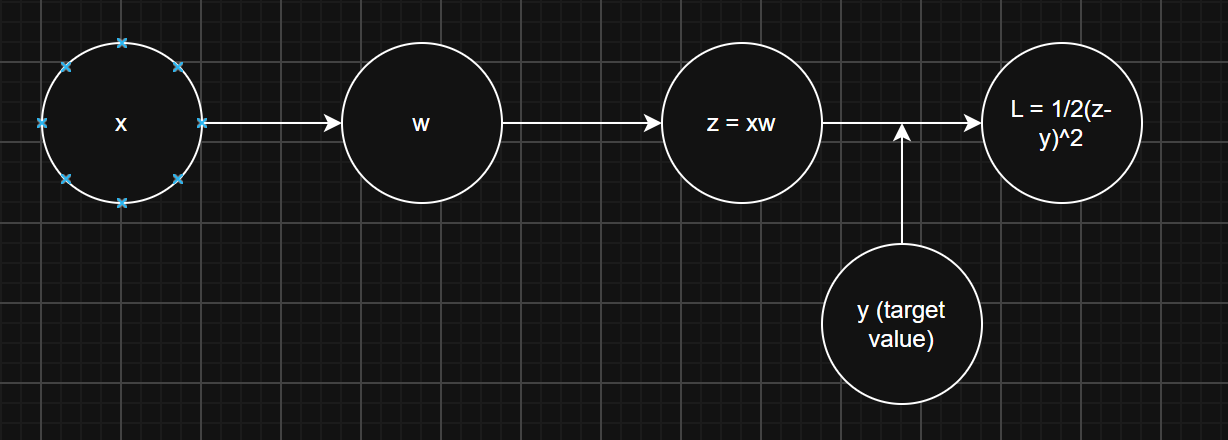

In [73]:
file_path_pic_35 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/35.png'
display(Image(filename=file_path_pic_35, width=600))

Cho $x = 2, w = 3, y = 10, L = \frac{1}{2}(xw-y)^2 = \frac{1}{2}(z-y)^2$

Forward pass:

$$
L = \frac{1}{2}(xw-y)^2 = 8
$$

Backward pass:

$$
\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial w} = (z-y)x = -8
$$

Giá trị âm thể hiện giá trị dự đoán đang thấp hơn so với target → Tăng giá trị dự đoán lên để làm giảm loss.

## Automatic Differentiation

Backpropagation is a special case of a general technique in numerical analysis called automatic differentiation.

We can think of automatic differentiation as a set of techniques to numerically (in contrast to symbolically) evaluate the exact (up to machine precision) gradient of a function by working with intermediate variables and applying the chain rule. By applying the chain rule to these operations, the gradient of quite complicated functions can be computed automatically.

Figure 5.10 shows a simple graph representing the data flow from inputs x to outputs y via some intermediate variables a, b. If we were to compute the derivative $dy/dx$, we would apply the chain rule and obtain

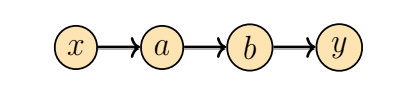

In [74]:
file_path_pic_36 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/36.png'
display(Image(filename=file_path_pic_36, width=600))

$$
\frac{dy}{dx} = \frac{dy}{db}\frac{db}{da}\frac{da}{dx}
$$

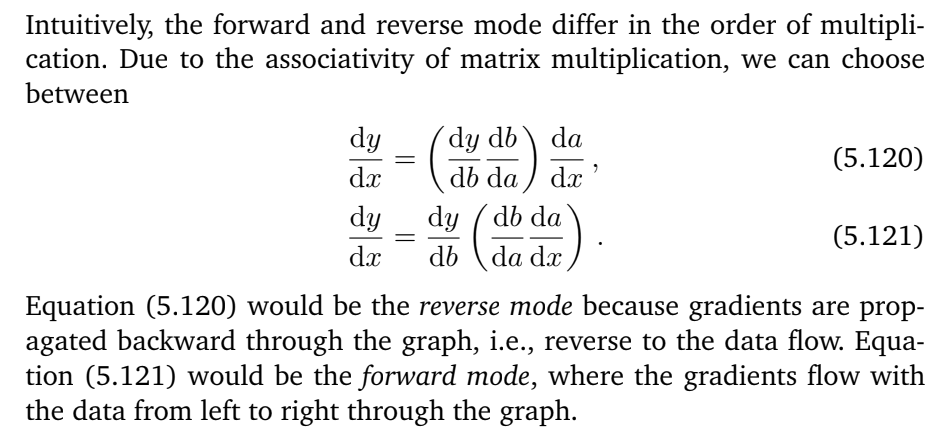

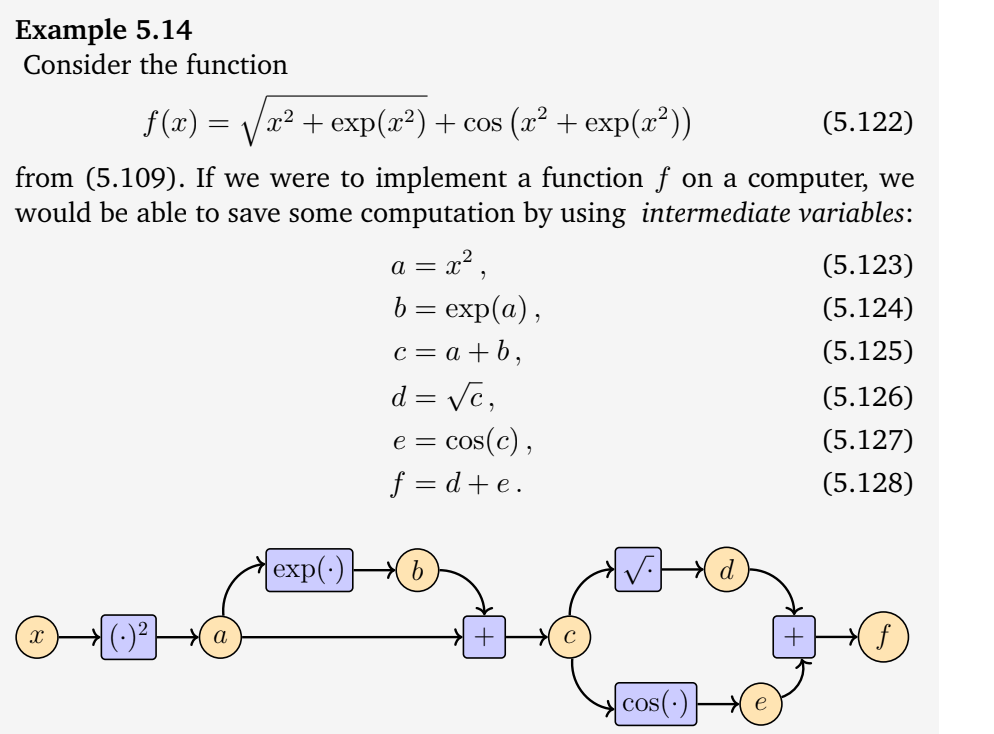

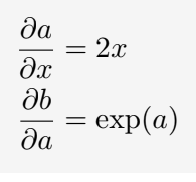

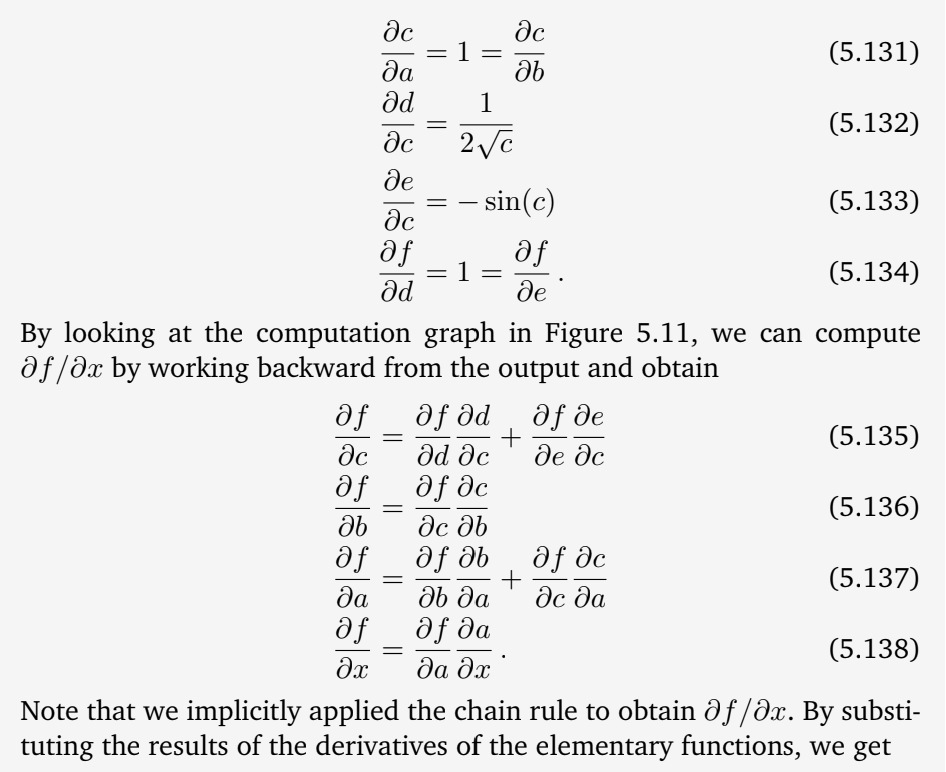

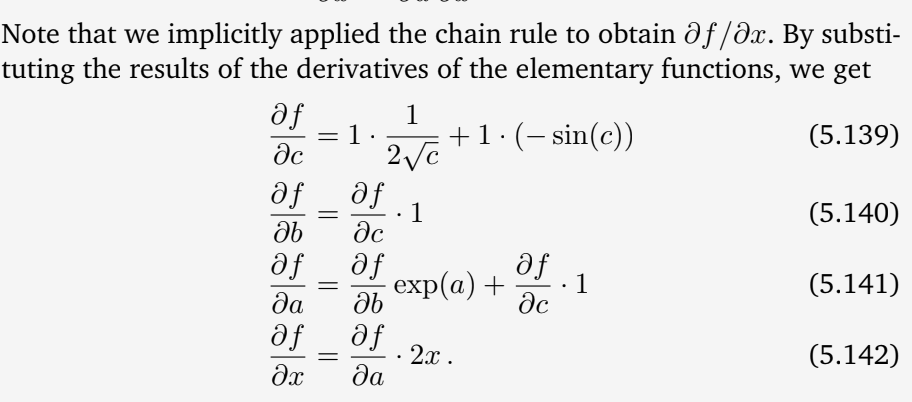

In [75]:
file_path_pic_37 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/37.png'
file_path_pic_38 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/38.png'
file_path_pic_39 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/39.png'
file_path_pic_40 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/40.png'
file_path_pic_41 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/41.png'
display(Image(filename=file_path_pic_37, width=600))
display(Image(filename=file_path_pic_38, width=600))
display(Image(filename=file_path_pic_39, width=600))
display(Image(filename=file_path_pic_40, width=600))
display(Image(filename=file_path_pic_41, width=600))

Những gì được trình bày ở trên là phương pháp tính toán đạo hàm theo backward pass, đi từ công thức gốc để tính toán là (5.135 → 5.138), sau đó thì tính toán dần các phần tử trong công thức.

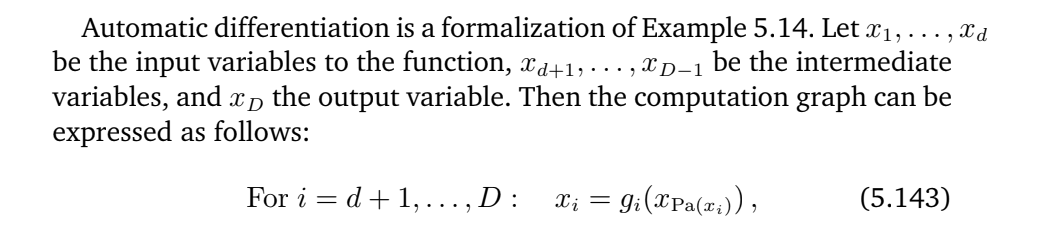

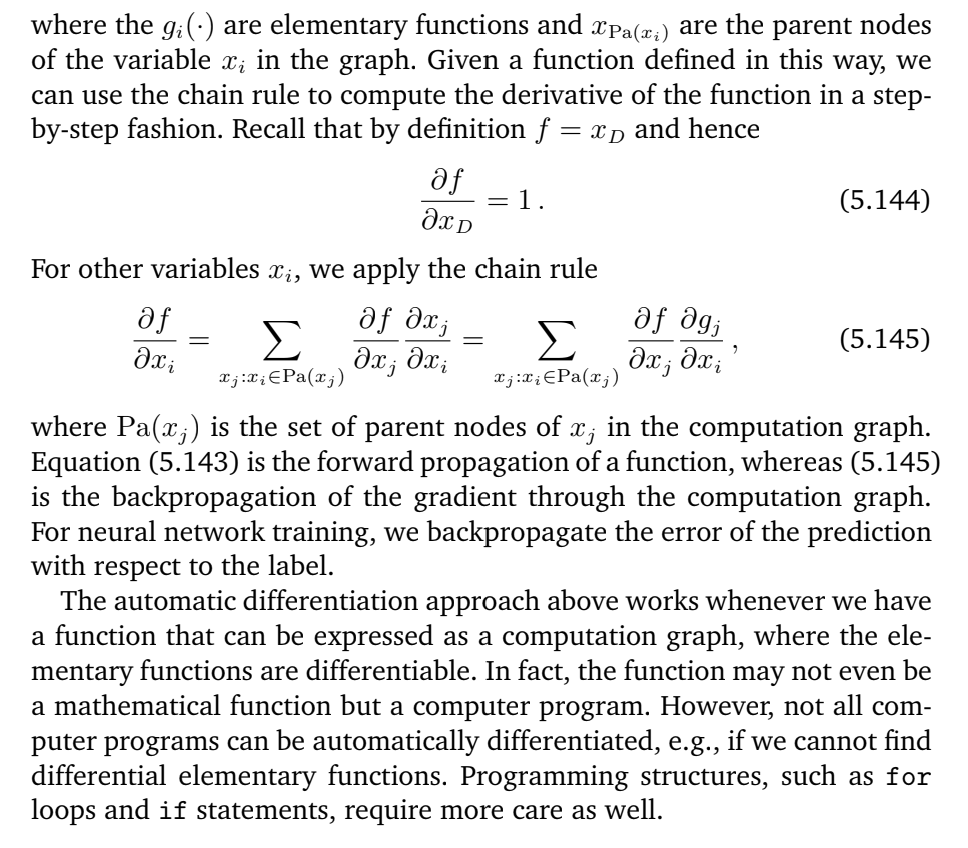

In [76]:
from IPython.core.interactiveshell import dis
file_path_pic_42 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/42.png'
file_path_pic_43 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/43.png'
display(Image(filename=file_path_pic_42, width=600))
display(Image(filename=file_path_pic_43, width=600))

Quá trình tính toán giá trị hàm số từ đầu vào đến đầu ra được biểu diễn qua phương trình:

$$
x_i = g_i(x_{\text{Pa}(x_i)})
$$

- Trong đó, $g_i(\cdot)$ gọi là các hàm sơ cấp (elementary functions).
- Ký hiệu $x_{\text{Pa}(x_i)}$ chỉ tập hợp các node cha (parent nodes) của biến $x_i$ trong đồ thị. Có nghĩa là giá trị của biến $x_i$ được tính toán trực tiếp dựa trên đầu vào là các nút cha của nó. Phương trình này mô tả quá trình lan truyền xuôi của một hàm số.

Trong hình trên thì tác giả cung cấp một công thức chuỗi tổng quát là (5.145), công thức này nói là để tìm đạo hàm truyền ngược về biến $x_i$, ta phải lấy tổng đạo hàm từ tất cả các biến $x_j$ mà $x_i$ là các node cha của nó.

Xét ví dụ sau đây

$$
f(x_1, x_2) = x_1 x_2 + x_1^2
$$

Xây dựng đồ thị tính toán:

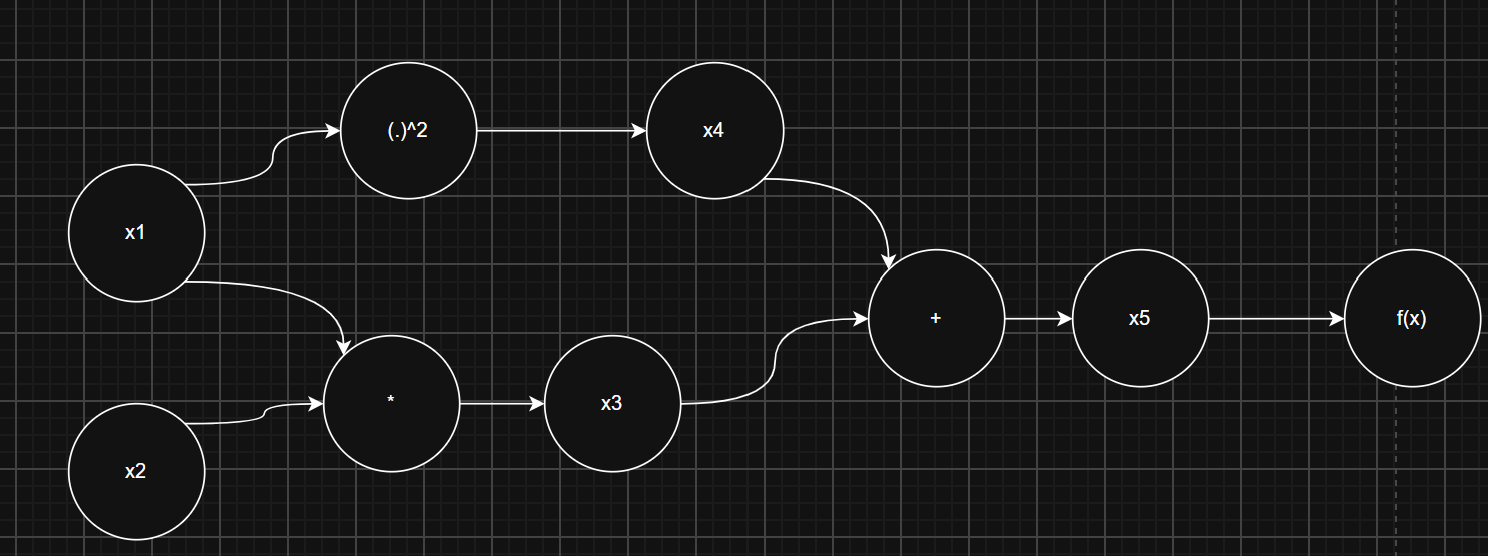

In [77]:
file_path_pic_44 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/44.png'
display(Image(filename=file_path_pic_44, width=600))

Trong đồ thị trên thì dễ thấy

$$
\frac{\partial f}{\partial x_5} = 1
$$

Giả sử muốn tìm $\frac{\partial f}{\partial x_3}$, ta trình bày như sau:

Vì node con của $x_3$ là $x_5$, nên ta có:

$$
\frac{\partial f}{\partial x_3} = \frac{\partial f}{\partial x_5}\frac{\partial x_5}{\partial x_3}
$$

Giả sử muốn tìm tiếp $\frac{\partial f}{\partial x_1}$, ta trình bày như sau:

Vì node con của $x_1$ là $x_4$ và $x_3$ nên ta có:

$$
\frac{\partial f}{\partial x_1} = \frac{\partial f}{\partial x_4}\frac{\partial x_4}{\partial x_1} + \frac{\partial f}{\partial x_3}\frac{\partial x_3}{\partial x_1}
$$

Để tính được cả 2 đạo hàm từng phần trên thì cần backpropagation từ $x_5$ truyền ngược về lần lượt $x_3$ và $x_1$.

## Linearization and Multivariate Taylor Series

The gradient $\nabla f$ of a function $f$ is often used for a locally linear approximation of $f$ around $x_0$.

$$
f(x) \approx f(x_0) + (\nabla_x f)(x_0)(x-x_0)
$$

$\nabla_x f$ is the gradient of $f$ with respect to $x$, evaluated at $x_0$.

The original function is approximated by a straight line. This approximation is locally accurate, but the farther we move away from $x_0$ the worse the approximation gets.

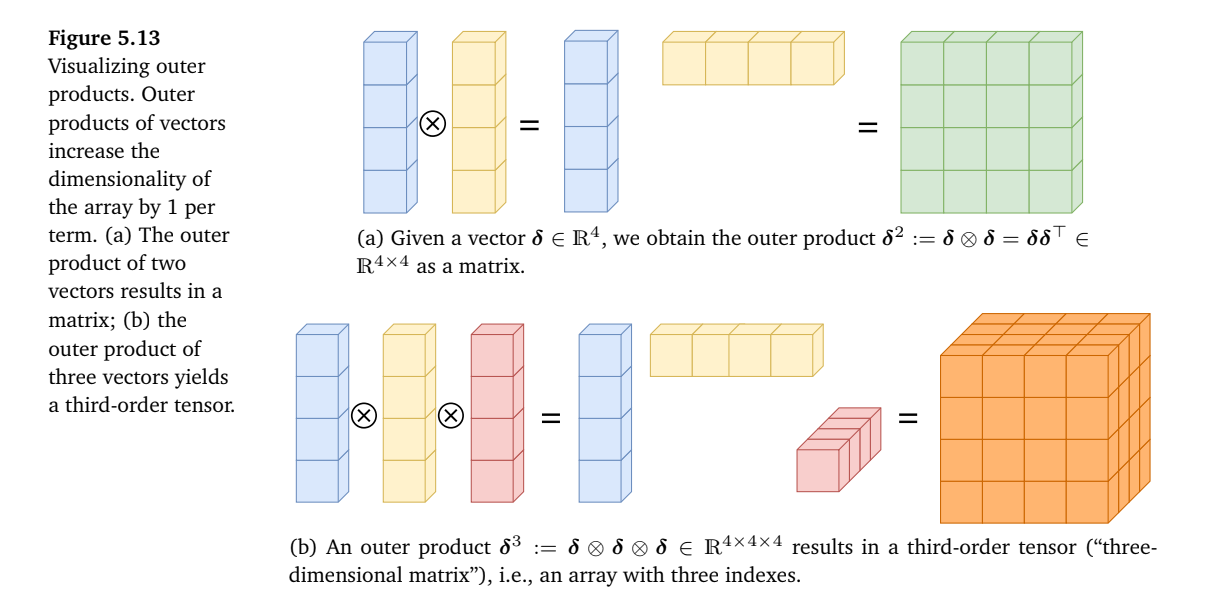

In [78]:
file_path_pic_45 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/45.png'
display(Image(filename=file_path_pic_45, width=600))

Hình này chỉ mô tả về tích ngoài, ôn lại một chút:

Cho $v \in \mathcal{R}^4 \setminus {\mathbf{\{0\}}}$, thì tích ngoài $vv^T \in \mathcal{R}^{4\times 4}$ có $rank(vv^T) = 1$

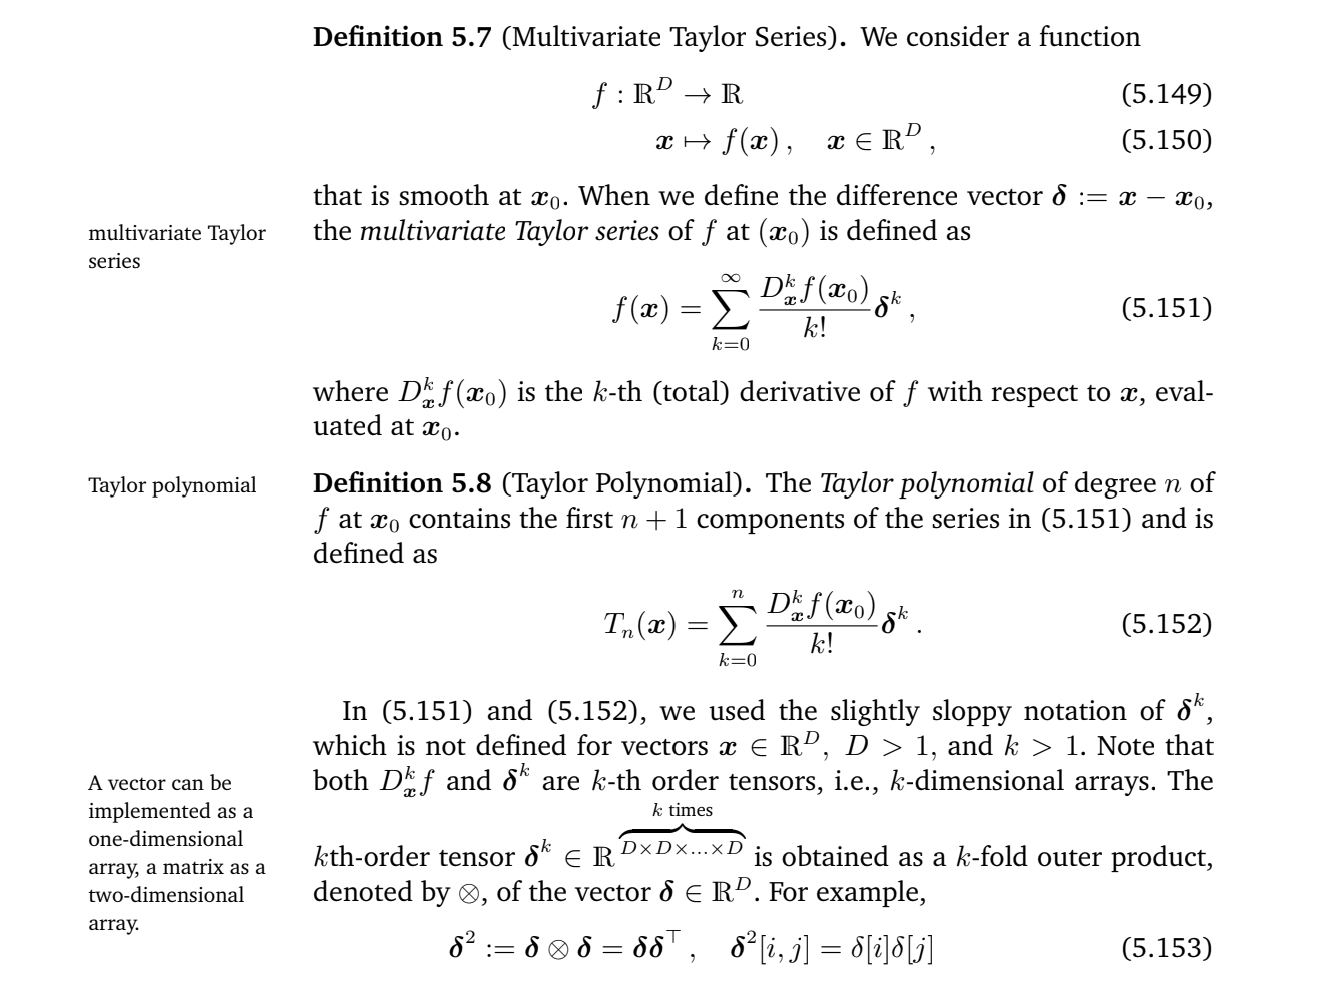

In [79]:
file_path_pic_46 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/46.png'
display(Image(filename=file_path_pic_46, width=600))

Trong đoạn trên thì tác giả định nghĩa Taylor series đa chiều, bậc $k$, với $\mathbf{x}$ thay vì là đơn biến thì bây giờ là đa biến, là một vector $D$ chiều.

Chú ý một chút về mặt kí hiệu:

- Nếu đặt $\delta = \mathbf{x} - \mathbf{x_0} \in \mathcal{R}^D$ thì đây được xem là một vector, nếu lấy tích của nó với chính nó thì ta được tích ngoài $\delta^2 := \delta \otimes \delta = \delta\delta^T \in \mathcal{R}^2$ do vậy nếu ta lấy $k$ vector $\delta$ nhân lại với nhau thì ta thu được một tensor $D$ chiều

$$
\delta^k := \delta \otimes \delta \otimes \dots \otimes \delta \text{(k times)} \in \mathcal{R}^{D\times D \times \dots \times D \text{(k times)}}
$$

- Và nếu sử dụng ký hiệu $\delta^k$ là không chặt chẽ vì ta không có định nghĩa số mũ cho một vector.

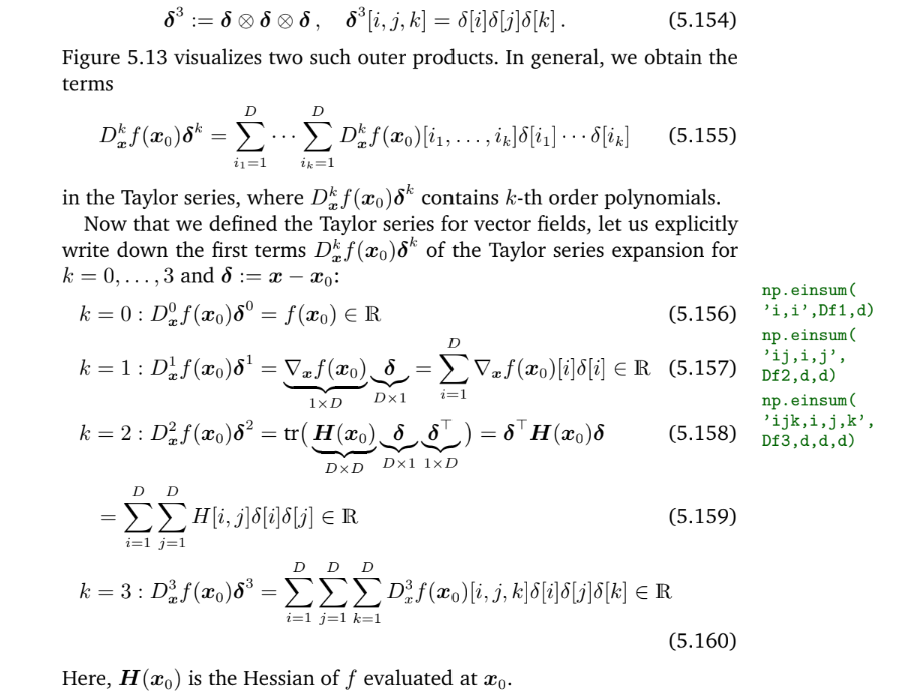

In [80]:
file_path_pic_47 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/47.png'
display(Image(filename=file_path_pic_47, width=600))

Có thể hiểu $\delta^3[i, j, k]$ như sau:

Bản chất của nó là một phép nhân mang theo thông tin độ biến thiên theo từng chiều  $i, j, k$ tức là nó là tích ngoài của $\delta[i]\delta[j]\delta[k]$

Tensor $k$ chiều $D^{k}_x f(\mathbf{x_0})$ mang theo thông tin của đạo hàm từng phần, tức là mỗi phần tử ở vị trí $D^{k}_x f(\mathbf{x_0})[i_1, i_2, \dots,i_k]$ trong tensor đều là đạo hàm từng phần của $f(\mathbf{x_0})$, và ta cần nhân chúng với độ biến thiên theo từng chiều $i_1, i_2,\dots, i_k$ để tạo ra công thức ban đầu của chuỗi Taylor, cuối cùng ta có công thức

$$
D^{k}_x f(\mathbf{x_0})[i_1, i_2, \dots,i_k]\delta[i_1]\delta[i_2]\dots\delta[i_k]
$$

Và ta cần duyệt qua hết tất cả các giá trị trong tensor $k$ chiều này

Vậy ta có công thức

$$
D^k_\mathbf{x}f(\mathbf{x_0})\delta^k=\sum_{i_1=1}^D \sum_{i_2 = 1}^D \dots \sum_{i_k=1}^D D^{k}_x f(\mathbf{x_0})[i_1, i_2, \dots,i_k]\delta[i_1]\delta[i_2]\dots\delta[i_k]
$$

Tác giả có đưa ra ví dụ trình bày với từng bậc $k$ thì chuỗi taylor đa biến, bậc cao sẽ trông thế nào

Giải thích một chút tại $k=2$,

Đặt $M = \delta\delta^T$ thì $M[i, j] = \delta[i]\delta[j]$.

Xét tiếp $C = HM$

$$
C[i, i] = \sum_{j=1}^D H[i, j]M[j, i] \Rightarrow \sum_{i=1}^DC[i, i] = \sum_{i=1}^D\sum_{j=1}^D H[i, j]M[j, i] = \sum_{i=1}^D\sum_{j=1}^D H[i, j]\delta[i]\delta[j]
$$

Rõ ràng thì về trái là $trace(C)$ hay $trace(H\delta\delta^T) = trace(\delta^TH\delta)$.

Từ trang 167 → 169 có trình bày một ví dụ nhỏ về phương pháp khai triển taylor với bậc cao, đa chiều.

# Dicussion

## Gradient and Jacobian Matrix/Linear Approximation

Trong mục này sẽ trình bày ma trận jacobian theo định dạng Denominator layout, và giải thích vì sao lại có sự khác biệt khi trình bày ma trận jacobian (Denominator/Numerator layout), bản chất vì sao lại có ma trận jacobian?

Nói qua lại một chút về xấp xỉ tuyến tính

Ta có khai triển Taylor bậc 1 cho hàm một biến $f: \mathcal{R} \to \mathcal{R}$ quanh điểm $x = x_0$ như sau:

$$
f(x) \approx f(x_0) + f'(x_0)(x-x_0)
$$

Đặt $\Delta x = x - x_0$ và $\Delta f = f(x) - f(x_0)$, ta có

$$
\Delta f \approx f'(x_0)\Delta x
$$

Nếu biểu diễn lại theo hàm có đầu vào là một vector và đầu ra là một số vô hướng, thì ta có như sau:

$$
f(\mathbf{x}) \approx f(\mathbf{x}_0) + \frac{\partial f}{\partial x_1}(x_1 - x_{1,0}) + \dots + \frac{\partial f}{\partial x_k}(x_k - x_{k,0})
$$

Hay

$$
\Delta f \approx \sum_{i=1}^k \frac{\partial f}{\partial x_i} \Delta x_i = \begin{bmatrix} \frac{\partial f}{\partial x_1} & \frac{\partial f}{\partial x_2} & \dots & \frac{\partial f}{\partial x_k} \end{bmatrix} \begin{bmatrix} \Delta x_1 \\ \Delta x_2 \\ \vdots \\ \Delta x_k \end{bmatrix}
$$

Viết lại đoạn trên như sau:

$$
\Delta f \approx \nabla_\mathbf{x} f(\mathbf{x_0})^T \Delta \mathbf{x}
$$

Hay nói cách khác, độ sai khác của hàm số một lượng nhỏ là $\Delta \mathbf{x}$ trong không gian Euclidean được đo bằng vector gradient $\nabla_\mathbf{x} f(\mathbf{x_0})^T$, đây cũng là giải thích cho ký hiệu khác nhau giữa sách [1] và sách [2] khi lấy gradient của một hàm vô hướng.

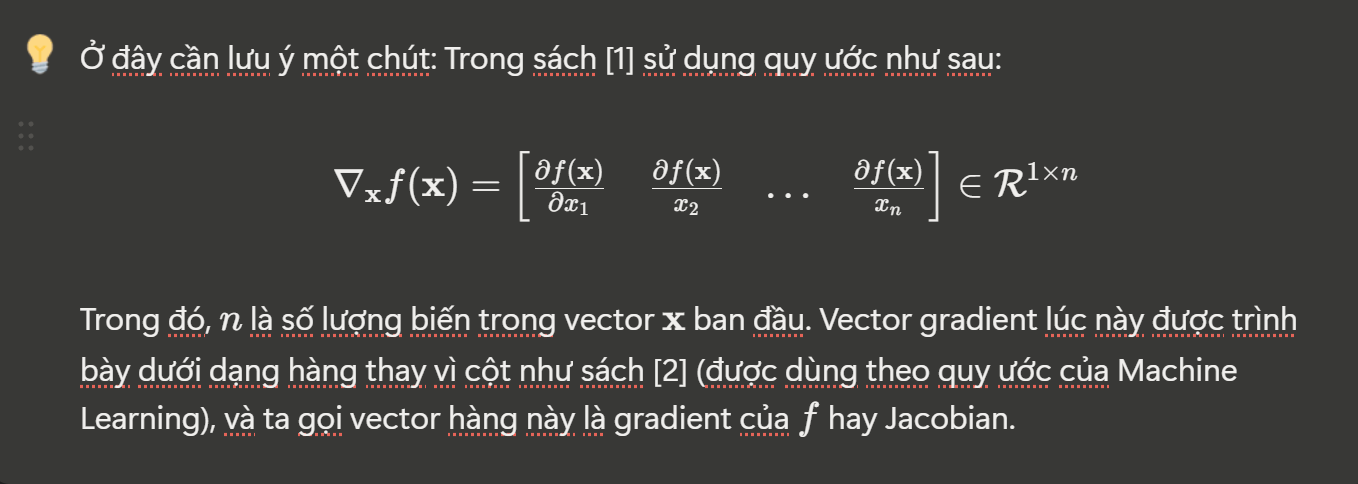

In [81]:
file_path_pic_48 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/48.png'
display(Image(filename=file_path_pic_48, width=600))

Ta xét tiếp trên hàm vector nhận và trả về vector $h(\mathbf{x}): \mathcal{R}^k \to \mathcal{R}^n$

Bây giờ, nếu đầu ra cũng là một vector $n$ chiều, mỗi thành phần $h_j(\mathbf{x})$ (với $j = 1, \dots, n$) đều là một hàm vô hướng của $\mathbf{x}$. Áp dụng xấp xỉ tuyến tính cho từng thành phần, ta có hệ phương trình:

$$
\begin{cases}  \Delta h_1 \approx \nabla h_1(\mathbf{x}_0)^T \Delta \mathbf{x} \\ \Delta h_2 \approx \nabla h_2(\mathbf{x}_0)^T \Delta \mathbf{x} \\ \vdots \\ \Delta h_n \approx \nabla h_n(\mathbf{x}_0)^T \Delta \mathbf{x} \end{cases}
$$

Gộp các vector gradient $\nabla h_j(\mathbf{x_0})^T$ này lại thành một vector gradient duy nhất, ta thu được ma trận được gọi là ma trận Jacobian

$$
\Delta \mathbf{h} \approx \begin{bmatrix} \nabla h_1(\mathbf{x}_0)^T \\ \nabla h_2(\mathbf{x}_0)^T \\ \vdots \\ \nabla h_n(\mathbf{x}_0)^T \end{bmatrix} \Delta \mathbf{x} = \mathbf{J}\Delta \mathbf{x}
$$

$$
J = \begin{bmatrix}  \frac{\partial h_1}{\partial x_1} & \frac{\partial h_1}{\partial x_2} & \dots & \frac{\partial h_1}{\partial x_k} \\ \frac{\partial h_2}{\partial x_1} & \frac{\partial h_2}{\partial x_2} & \dots & \frac{\partial h_2}{\partial x_k} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial h_n}{\partial x_1} & \frac{\partial h_n}{\partial x_2} & \dots & \frac{\partial h_n}{\partial x_k} \end{bmatrix} \in \mathbb{R}^{n \times k}
$$

Và đây cũng là ma trận Jacobian được trình bày trong sách [1]

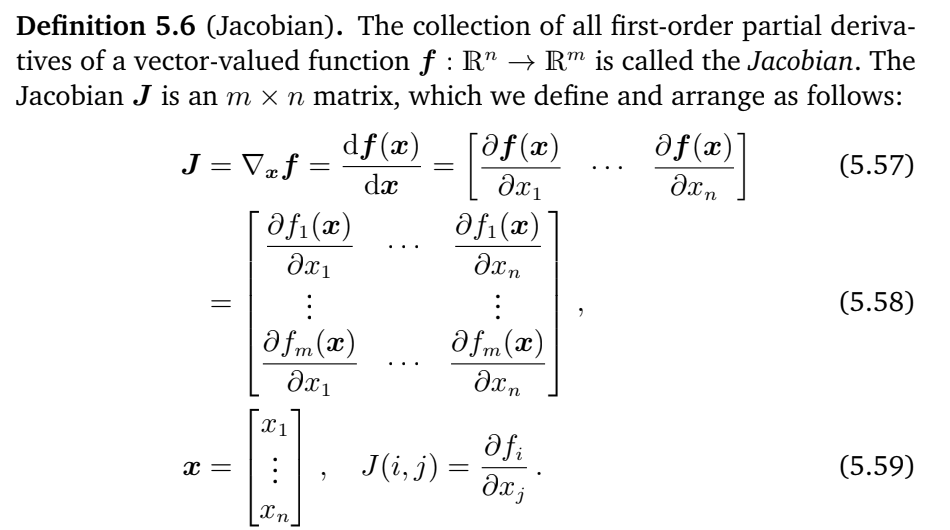

In [82]:
file_path_pic_49 = '/content/drive/MyDrive/Hình project google colab/matrix_calculus_gradient/49.png'
display(Image(filename=file_path_pic_49, width=600))

Tuy nhiên, trong máy học thì ta không sử dụng trực tiếp ma trận jacobian mà ta dùng chuyển vị của ma trận này (trong sách [2]), như sau

$$
\nabla h(\mathbf{x}) = \begin{bmatrix} \nabla h_1(\mathbf{x}) & \nabla h_2(\mathbf{x}) & \dots & \nabla h_n(\mathbf{x}) \end{bmatrix} \in \mathbb{R}^{k \times n}
$$

$$
\nabla h(\mathbf{x}) = J^T
$$

Lý do là để thực hiện các bài toán tối ưu hóa và chain rule trong neural network dễ hơn

Ta biết các hidden layer trong neural network là các hàm vector $h(\mathbf{x}): \mathcal{R}^k \to \mathcal{R}^n$, sau đó thì đầu ra của hàm vector này sẽ được đưa vào một hàm mất mát vô hướng $L = g(h)$, trong đó $g: \mathcal{R}^n \to \mathcal{R}$.

Ta có:

1. **Theo xấp xỉ tuyến tính tầng cuối:**
    
    $$
    \Delta L \approx \nabla_{\mathbf{h}} L^T \cdot \Delta \mathbf{h}
    $$
    
2. **Theo xấp xỉ tuyến tính tầng ẩn:**

$$
\Delta \mathbf{h} \approx J \cdot \Delta \mathbf{x}
$$

$$
\Rightarrow \Delta L \approx \nabla_{\mathbf{h}} L^T \cdot (J \cdot \Delta \mathbf{x}) = (\nabla_{\mathbf{h}} L^T J) \cdot \Delta \mathbf{x}
$$

Mà ta còn phép xấp xỉ tuyến tính sau

$$
\Delta L \approx \nabla_{\mathbf{x}} L^T \cdot \Delta \mathbf{x}
$$

$$
\Rightarrow \nabla_\mathbf{x}L^T = \nabla_\mathbf{h}L^TJ
$$

$$
\Leftrightarrow \nabla_\mathbf{x}L = J^T \nabla_\mathbf{h}L
$$

Mà $J^T = \nabla h(\mathbf{x})$

$$
\Leftrightarrow \nabla_\mathbf{x}L = \nabla h(\mathbf{x}) \nabla_\mathbf{h}L
$$

Mà $\nabla_\mathbf{x}L \in \mathcal{R}^{k \times 1}$ và $\nabla_{\mathbf{h}} L \in \mathcal{R}^{n\times 1}$, vậy thì bắt buộc $\nabla h(\mathbf{x}) = J^T \in \mathcal{R}^{k \times n}$

Qua đó thì có thể thấy được thay vì dùng $J$ thì ta sử dụng $J^T$ ngay từ đầu sẽ thuận tiện cho việc tính toán hơn, đỡ mất công phải chuyển vị ma trận, làm tiêu tốn tài nguyên tính toán.

## Linear Approximation, Gradient, and Loss Function

Ngoài ra còn có một tính chất khá hay của Gradient nữa như sau:

Gradient $\nabla_w L(\mathbf{w})$ là vector trỏ về hướng giá trị hàm mất mát $L(\mathbf{w})$ tăng

Lại quay lại với xấp xỉ tuyến tính, ta xấp xỉ sự thay đổi rất nhỏ $\epsilon > 0$ của hàm số theo hướng đi $\mathbf{u}$ bất kỳ sao cho $\left\|\mathbf{u}\right\| = 1$, ta sử dụng phép xấp xỉ tuyến tính nói trên

Theo khai triển Taylor, ta có:

$$
L(\mathbf{w} + \epsilon\mathbf{u}) \approx L(\mathbf{w}) + \nabla L(\mathbf{w})\cdot(\epsilon \mathbf{u})
$$

Viết lại

$$
\Delta L \approx \epsilon(\nabla L(\mathbf{w})\cdot\mathbf{u})
$$

Vậy thì để hàm mất mát tăng với ràng buộc $\epsilon > 0$ thì buộc tích vô hướng $\nabla L(\mathbf{w})\cdot\mathbf{u} > 0$

Mà



$$
\nabla L(\mathbf{w})\cdot\mathbf{u} = \left\|\nabla L(\mathbf{w})\right\| \left\|\mathbf{u}\right\| \cos(\theta)
$$

Trong đó $\theta$ là góc giữa vector gradient và $\mathbf{u}$, dẫn tới

$$
\left\|\nabla L(\mathbf{w})\right\| \left\|\mathbf{u}\right\| \cos(\theta) > 0
$$

$$
\Rightarrow \cos(\theta) > 0
$$

Tức là ta chỉ cần chọn ra vector $\mathbf{u}$ sao cho cùng chiều với gradient hoặc ít nhất thì góc tạo bởi 2 vector phải nằm trong khoảng $\frac{-\pi}{2} < \theta < \frac{\pi}{2}$, thì sẽ khiến cho loss function tăng lên. Nói cách khác thì câu khẳng định trên là có cơ sở.

# References
[1]: Mathematics for Machine Learning - Section 5. Vector Calculus

[2]: Machine Learning cơ bản - Vũ Hữu Tiệp